# Water-quality clustering with log-transformed turbidity

This notebook keeps the current sensor-specific KMeans and cluster-labeling
pipeline as close as possible to the existing version.

The main methodological change is:

- `turbidity_log1p = log(1 + turbidity_NTU)` is calculated before scaling;
- KMeans uses robust-scaled **log-transformed turbidity**;
- the turbidity contribution in the quality score uses the same transformed
  and scaled turbidity;
- the original `turbidity_NTU` column is retained unchanged for interpretation,
  plots, summaries, and dashboard output.

Sensors **977** and **981** still exclude oxygen saturation from clustering and
quality-score calculation.

No PCA is used.


In [2]:
import importlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# The dashboard/inspection helpers are optional.
# The clustering pipeline can run even if funcs.py is temporarily unavailable.
try:
    import funcs
    importlib.reload(funcs)

    from funcs import (
        inspect_sensors,
        build_latest_sensor_statuses,
        plot_sensors,
    )
except (ImportError, AttributeError) as error:
    inspect_sensors = None
    build_latest_sensor_statuses = None
    print(f"Optional funcs.py helpers were not loaded: {error}")


## 1. Load the cleaned data

When `df_model` already exists in the notebook session, it is used directly.
Otherwise, the model-ready CSV is loaded.


In [5]:
DATA_PATH = r"C:\Users\User\Desktop\water\data\water_model_ready2.csv"

if "df_model" in globals() and isinstance(df_model, pd.DataFrame):
    df = df_model.copy()
    print("Using the existing dataframe: df_model")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded: {DATA_PATH}")

print(f"Rows loaded: {len(df):,}")
display(df.head())


Loaded: C:\Users\User\Desktop\water\data\water_model_ready2.csv
Rows loaded: 19,857


,date_insert,sensor_id,id,year,month,day,hour,lat,lng,wtempV_°C,...,turbidity_NTU__statistical_suspect,any_statistical_suspect,oxygen_mean_24h,oxygen_std_24h,oxygen_mean_7d,oxygen_7d_change_vs_3d_ago,oxygen_low_24h_flag,oxygen_noisy_24h_flag,oxygen_downward_drift_flag,oxygen_sensor_suspect
0,2025-07-03 15:00:00,976,3.0,2025.0,7.0,3.0,15.0,38.310409,21.784038,24.96,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
1,2025-07-03 16:00:00,976,12.0,2025.0,7.0,3.0,16.0,38.310409,21.784038,25.16,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
2,2025-07-03 17:00:00,976,21.0,2025.0,7.0,3.0,17.0,38.310409,21.784038,24.70,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
3,2025-07-03 18:00:00,976,30.0,2025.0,7.0,3.0,18.0,38.310409,21.784038,24.63,...,False,False,NaN,NaN,NaN,NaN,False,False,False,False
4,2025-07-03 21:00:00,976,57.0,2025.0,7.0,3.0,21.0,38.310409,21.784038,24.55,...,False,False,95.03375,1.294096,NaN,NaN,False,False,False,False


## 2. Configuration

The scoring formula is converted to a weighted average. This keeps three-feature scores for sensors 977 and 981 more comparable with the four-feature scores used for the other sensors.


In [3]:
sensor_id_col = "sensor_id"
timestamp_col = "date_insert"

conductivity_col = "conductivity_of_solution_ mS_cm"
orp_col = "oxidation_reduction_potential_ mV"
oxygen_col = "oxygen_saturation_%"
turbidity_col = "turbidity_NTU"
turbidity_log_col = "turbidity_log1p"

all_features = [
    conductivity_col,
    orp_col,
    oxygen_col,
    turbidity_col,
]

three_feature_set = [
    conductivity_col,
    orp_col,
    turbidity_col,
]

N_CLUSTERS = 3
RANDOM_STATE = 42

# Oxygen is considered unreliable for these sensors.
OXYGEN_EXCLUDED_SENSORS = {977, 981}

# Weights used when K-means creates the clusters.
clustering_weights = {
    conductivity_col: 1.0,
    orp_col: 2.0,
    oxygen_col: 0.8,
    turbidity_col: 2.0,
}

# Weights used when interpreting and labelling the clusters.
label_weights = {
    "conductivity_deviation": 1.0,
    "orp": 2.0,
    "oxygen": 0.8,
    "turbidity": 2.0,
}


def features_for_sensor(sensor_id):
    """Return the trusted clustering features for one sensor."""
    if sensor_id in OXYGEN_EXCLUDED_SENSORS:
        return three_feature_set.copy()

    return all_features.copy()


## 3. Validate columns and retain usable rows

Rows from sensors 977 and 981 are allowed to have missing oxygen values because
oxygen is not used for those sensors. Other sensors still require all four
measurements.

No duplicate-removal step is included.


In [4]:
required_columns = [
    sensor_id_col,
    conductivity_col,
    orp_col,
    oxygen_col,
    turbidity_col,
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        f"The following required columns are missing: {missing_columns}"
    )

input_df = df.copy().reset_index(drop=True)
input_df["_source_row_id"] = np.arange(len(input_df))

usable_parts = []
row_audit = []

for sensor, sensor_df in input_df.groupby(
    sensor_id_col,
    sort=False,
):
    active_features = features_for_sensor(sensor)

    usable_mask = sensor_df[active_features].notna().all(axis=1)
    usable_sensor_df = sensor_df.loc[usable_mask].copy()

    usable_parts.append(usable_sensor_df)

    row_audit.append({
        sensor_id_col: sensor,
        "features_used": ", ".join(active_features),
        "input_rows": len(sensor_df),
        "usable_rows": int(usable_mask.sum()),
        "excluded_rows": int((~usable_mask).sum()),
        "oxygen_used_in_model": sensor not in OXYGEN_EXCLUDED_SENSORS,
    })

if not usable_parts:
    raise ValueError("No rows were usable for clustering.")

work_df = (
    pd.concat(usable_parts, axis=0)
    .sort_values("_source_row_id")
    .reset_index(drop=True)
)

# Use a fresh, contiguous row ID for alignment inside this notebook.
work_df["_row_id"] = np.arange(len(work_df))

row_audit_df = pd.DataFrame(row_audit)

print(f"Rows available for clustering: {len(work_df):,}")
print(f"Sensors available: {work_df[sensor_id_col].nunique()}")
display(row_audit_df)


Rows available for clustering: 19,857
Sensors available: 9


,sensor_id,features_used,input_rows,usable_rows,excluded_rows,oxygen_used_in_model
0,976,"conductivity_of_solution_ mS_cm, oxidation_red...",1257,1257,0,True
1,977,"conductivity_of_solution_ mS_cm, oxidation_red...",1848,1848,0,False
2,978,"conductivity_of_solution_ mS_cm, oxidation_red...",1584,1584,0,True
3,979,"conductivity_of_solution_ mS_cm, oxidation_red...",3441,3441,0,True
4,980,"conductivity_of_solution_ mS_cm, oxidation_red...",2208,2208,0,True
5,981,"conductivity_of_solution_ mS_cm, oxidation_red...",986,986,0,False
6,982,"conductivity_of_solution_ mS_cm, oxidation_red...",3126,3126,0,True
7,983,"conductivity_of_solution_ mS_cm, oxidation_red...",2523,2523,0,True
8,984,"conductivity_of_solution_ mS_cm, oxidation_red...",2884,2884,0,True


## 4. Log-transform turbidity, then robust-scale the features

Turbidity is transformed with:

`log1p(turbidity) = log(1 + turbidity)`

This compresses differences at the high end while preserving ordering.

The original `turbidity_NTU` values remain unchanged in `work_df`.

A separate `RobustScaler` is then fitted for every measurement. For turbidity,
the scaler is fitted to `turbidity_log1p`, not raw NTU.

The oxygen scaler is fitted only on sensors whose oxygen channel is trusted.


In [5]:
# Turbidity should be non-negative after cleaning.
negative_turbidity = work_df[turbidity_col] < 0

if negative_turbidity.any():
    raise ValueError(
        f"Found {negative_turbidity.sum()} negative turbidity values. "
        "Inspect the cleaning pipeline before applying log1p."
    )

# Keep the original NTU values and create a separate transformed column.
work_df[turbidity_log_col] = np.log1p(
    work_df[turbidity_col]/30
)

print("Raw vs log-transformed turbidity:")
display(
    work_df[
        [turbidity_col, turbidity_log_col]
    ].describe()
)


feature_scalers = {}

# For compatibility with the existing code, this dataframe keeps the original
# feature names. The turbidity column below contains robust-scaled
# log1p(turbidity_NTU), not robust-scaled raw turbidity.
scaled_feature_df = pd.DataFrame(
    index=work_df.index,
    columns=all_features,
    dtype=float,
)

for feature in all_features:

    source_column = (
        turbidity_log_col
        if feature == turbidity_col
        else feature
    )

    fit_mask = work_df[source_column].notna()

    if feature == oxygen_col:
        fit_mask &= ~work_df[sensor_id_col].isin(
            OXYGEN_EXCLUDED_SENSORS
        )

    if fit_mask.sum() == 0:
        raise ValueError(
            f"No trusted non-missing values were available for {feature}."
        )

    scaler = RobustScaler()
    scaler.fit(
        work_df.loc[
            fit_mask,
            [source_column],
        ]
    )

    feature_scalers[feature] = scaler

    transform_mask = work_df[source_column].notna()

    scaled_feature_df.loc[
        transform_mask,
        feature,
    ] = (
        scaler.transform(
            work_df.loc[
                transform_mask,
                [source_column],
            ]
        ).ravel()
    )

# Weighted feature space used by KMeans.
df_scaled = scaled_feature_df.copy()

for feature, weight in clustering_weights.items():
    df_scaled[feature] = (
        df_scaled[feature] * weight
    )

display(df_scaled.head())


Raw vs log-transformed turbidity:


,turbidity_NTU,turbidity_log1p
count,19857.000000,19857.000000
mean,238.907588,1.867555
std,198.848208,0.882102
min,0.100000,0.003328
25%,78.800000,1.288314
50%,194.190000,2.011297
75%,353.670000,2.548585
max,999.030000,3.535175


,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
0,0.104039,-2.261428,0.736116,-1.119297
1,-0.201635,-2.265465,0.729341,0.417086
2,0.079410,-2.257997,0.741682,-0.136752
3,0.117004,-2.260755,0.751361,0.126159
4,0.130513,-2.307309,0.656019,-1.679563


## 5. Fit one KMeans model per sensor

Sensors 977 and 981 are clustered in a three-dimensional feature space.
The remaining sensors are clustered in a four-dimensional feature space.

For every sensor, the turbidity dimension is based on
**robust-scaled log-transformed turbidity**.

The previous distinct/duplicate-point check is omitted.


In [6]:
processed_sensor_dfs = []
skipped_sensors = []

sensor_kmeans_models = {}
sensor_feature_sets = {}

for sensor, sensor_indices in work_df.groupby(
    sensor_id_col,
    sort=False,
).groups.items():

    sensor_indices = pd.Index(sensor_indices)
    active_features = features_for_sensor(sensor)

    sensor_data = df_scaled.loc[
        sensor_indices,
        active_features,
    ]

    original_sensor_data = work_df.loc[
        sensor_indices
    ].copy()

    if len(sensor_data) < N_CLUSTERS:
        skipped_sensors.append({
            sensor_id_col: sensor,
            "reason": "Fewer rows than clusters",
        })
        continue

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=20,
    )

    original_sensor_data["cluster"] = (
        kmeans.fit_predict(sensor_data)
    )

    original_sensor_data["oxygen_used_in_model"] = (
        sensor not in OXYGEN_EXCLUDED_SENSORS
    )

    original_sensor_data["model_features"] = (
        ", ".join(active_features)
        + " [turbidity uses log1p]"
    )

    sensor_kmeans_models[sensor] = kmeans
    sensor_feature_sets[sensor] = active_features

    processed_sensor_dfs.append(original_sensor_data)

if not processed_sensor_dfs:
    raise ValueError(
        "No sensor contained enough data to form three clusters."
    )

clustered_df = (
    pd.concat(processed_sensor_dfs, axis=0)
    .sort_values("_row_id")
)

print(f"Clustered rows: {len(clustered_df):,}")
print(f"Clustered sensors: {clustered_df[sensor_id_col].nunique()}")

if skipped_sensors:
    print("\nSkipped sensors:")
    display(pd.DataFrame(skipped_sensors))


Clustered rows: 19,857
Clustered sensors: 9


## 6. Calculate measurement-level quality scores

Positive contributions increase concern:

- higher **log-transformed turbidity**;
- lower ORP;
- lower oxygen saturation, when oxygen is trusted;
- conductivity farther from the sensor's usual range.

For sensors 977 and 981, oxygen contribution is exactly zero.

The total is divided by the sum of active weights so that three-feature and
four-feature scores remain on a comparable scale.

Because `scaled_feature_df[turbidity_col]` now contains robust-scaled
`log1p(turbidity_NTU)`, the existing turbidity contribution automatically uses
the transformed turbidity.


In [7]:
label_scaled_df = pd.DataFrame(
    index=work_df.index,
)

# This is robust-scaled log1p(turbidity_NTU), not scaled raw NTU.
label_scaled_df["scaled_turbidity"] = (
    scaled_feature_df[turbidity_col]
)

label_scaled_df["scaled_orp"] = (
    scaled_feature_df[orp_col]
)

label_scaled_df["scaled_oxygen"] = (
    scaled_feature_df[oxygen_col]
)


# Conductivity is interpreted as deviation from each sensor's normal range.
conductivity_group = work_df.groupby(
    sensor_id_col
)[conductivity_col]

conductivity_median = conductivity_group.transform("median")

conductivity_q1 = conductivity_group.transform(
    lambda values: values.quantile(0.25)
)

conductivity_q3 = conductivity_group.transform(
    lambda values: values.quantile(0.75)
)

conductivity_iqr = (
    conductivity_q3 - conductivity_q1
).replace(0, np.nan)

label_scaled_df["conductivity_deviation"] = (
    (
        work_df[conductivity_col] - conductivity_median
    ).abs()
    / conductivity_iqr
).fillna(0).clip(lower=0, upper=5)


label_scaled_df["turbidity_contribution"] = (
    label_weights["turbidity"]
    * label_scaled_df["scaled_turbidity"]
)

label_scaled_df["orp_contribution"] = (
    -label_weights["orp"]
    * label_scaled_df["scaled_orp"]
)

oxygen_is_active = ~work_df[sensor_id_col].isin(
    OXYGEN_EXCLUDED_SENSORS
)

label_scaled_df["oxygen_contribution"] = np.where(
    oxygen_is_active,
    -label_weights["oxygen"]
    * label_scaled_df["scaled_oxygen"],
    0.0,
)

label_scaled_df["conductivity_contribution"] = (
    label_weights["conductivity_deviation"]
    * label_scaled_df["conductivity_deviation"]
)

label_scaled_df["active_weight_sum"] = (
    label_weights["turbidity"]
    + label_weights["orp"]
    + label_weights["conductivity_deviation"]
    + np.where(
        oxygen_is_active,
        label_weights["oxygen"],
        0.0,
    )
)

contribution_columns = [
    "turbidity_contribution",
    "orp_contribution",
    "oxygen_contribution",
    "conductivity_contribution",
]

label_scaled_df["measurement_quality_score"] = (
    label_scaled_df[contribution_columns].sum(axis=1)
    / label_scaled_df["active_weight_sum"]
)

display(
    label_scaled_df[
        [
            "scaled_turbidity",
            "scaled_orp",
            "scaled_oxygen",
            "conductivity_deviation",
            *contribution_columns,
            "active_weight_sum",
            "measurement_quality_score",
        ]
    ].describe()
)


,scaled_turbidity,scaled_orp,scaled_oxygen,conductivity_deviation,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,active_weight_sum,measurement_quality_score
count,19857.000000,19857.000000,19443.000000,19857.000000,19857.000000,19857.000000,19857.000000,19857.000000,19857.000000,19857.000000
mean,-0.114056,-0.088790,-0.129111,0.744208,-0.228113,0.177580,0.039107,0.744208,5.685824,0.129739
std,0.699930,0.559611,0.915071,0.876329,1.399861,1.119221,0.683226,0.876329,0.279837,0.409110
min,-1.593283,-1.699889,-1.972172,0.000000,-3.186565,-1.435770,-3.180883,0.000000,5.000000,-0.872310
25%,-0.573672,-0.560866,-0.587114,0.219289,-1.147344,-0.878267,-0.358137,0.219289,5.800000,-0.149503
50%,0.000000,0.000000,-0.083485,0.449413,0.000000,0.000000,0.000000,0.449413,5.800000,0.153763
75%,0.426328,0.439134,0.479734,0.906386,0.852656,1.121733,0.268119,0.906386,5.800000,0.390258
max,1.209166,0.717885,3.976104,5.000000,2.418333,3.399778,1.577737,5.000000,5.800000,1.582057


In [8]:
clustered_df["measurement_quality_score"] = (
    label_scaled_df.loc[
        clustered_df["_row_id"],
        "measurement_quality_score",
    ].to_numpy()
)


## 7. Summarize and label clusters

The cluster label is based on the median quality score of the cluster. Global one-third and two-third cutoffs are applied to the weighted-average scores.


In [9]:
cluster_quality = (
    clustered_df
    .groupby(
        [sensor_id_col, "cluster"],
        as_index=False,
    )
    .agg(
        cluster_quality_score=(
            "measurement_quality_score",
            "median",
        ),
        mean_quality_score=(
            "measurement_quality_score",
            "mean",
        ),
        median_turbidity=(
            turbidity_col,
            "median",
        ),
        median_log_turbidity=(
            turbidity_log_col,
            "median",
        ),
        median_orp=(
            orp_col,
            "median",
        ),
        median_oxygen=(
            oxygen_col,
            "median",
        ),
        median_conductivity=(
            conductivity_col,
            "median",
        ),
        observations=(
            "cluster",
            "size",
        ),
        oxygen_used_in_model=(
            "oxygen_used_in_model",
            "first",
        ),
        model_features=(
            "model_features",
            "first",
        ),
    )
    .sort_values("cluster_quality_score")
    .reset_index(drop=True)
)

ok_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(0.25)

danger_cutoff = cluster_quality[
    "cluster_quality_score"
].quantile(0.75)

cluster_quality["Water_Quality_Label"] = np.select(
    [
        cluster_quality["cluster_quality_score"] <= ok_cutoff,
        cluster_quality["cluster_quality_score"] < danger_cutoff,
    ],
    [
        "Ok",
        "Medium",
    ],
    default="Danger",
)

print(f"Ok cutoff:     {ok_cutoff:.4f}")
print(f"Danger cutoff: {danger_cutoff:.4f}")

display(
    cluster_quality.sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)


Ok cutoff:     -0.2714
Danger cutoff: 0.3277


,sensor_id,cluster,cluster_quality_score,mean_quality_score,median_turbidity,median_log_turbidity,median_orp,median_oxygen,median_conductivity,observations,oxygen_used_in_model,model_features,Water_Quality_Label
9,976,2,-0.039165,-0.018973,35.290,0.777642,-140.750,93.340,56890.520,453,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
19,976,0,0.320349,0.311640,147.380,1.777097,-116.215,87.745,56989.480,614,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
25,976,1,0.547025,0.545953,235.705,2.181189,-98.420,55.420,57012.280,190,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
16,977,1,0.246924,0.228851,392.980,2.646127,217.495,0.000,56617.220,400,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
24,977,0,0.534134,0.503622,184.965,1.969278,-169.145,32.430,58717.845,544,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
26,977,2,0.883851,0.909368,446.300,2.764850,-157.560,55.270,58526.070,904,False,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
7,978,1,-0.238132,-0.201224,21.910,0.548314,-16.850,91.900,56699.090,425,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
18,978,2,0.292091,0.286737,342.490,2.519011,-0.325,86.860,55910.770,670,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium
22,978,0,0.429275,0.598704,641.340,3.108078,76.740,89.450,55834.420,489,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Danger
13,979,2,0.061193,0.032587,28.795,0.672858,65.790,65.860,58037.400,220,True,"conductivity_of_solution_ mS_cm, oxidation_red...",Medium


In [10]:
cluster_label_information = cluster_quality[
    [
        sensor_id_col,
        "cluster",
        "cluster_quality_score",
        "Water_Quality_Label",
    ]
]

final_training_df = clustered_df.merge(
    cluster_label_information,
    on=[sensor_id_col, "cluster"],
    how="left",
    validate="many_to_one",
)

final_training_df = (
    final_training_df
    .sort_values("_row_id")
    .reset_index(drop=True)
)

display(final_training_df.head())


,date_insert,sensor_id,id,year,month,day,hour,lat,lng,wtempV_°C,...,oxygen_noisy_24h_flag,oxygen_downward_drift_flag,oxygen_sensor_suspect,turbidity_log1p,cluster,oxygen_used_in_model,model_features,measurement_quality_score,cluster_quality_score,Water_Quality_Label
0,2025-07-03 15:00:00,976,3.0,2025.0,7.0,3.0,15.0,38.310409,21.784038,24.96,...,False,False,False,1.305988,2,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.134499,-0.039165,Medium
1,2025-07-03 16:00:00,976,12.0,2025.0,7.0,3.0,16.0,38.310409,21.784038,25.16,...,False,False,False,2.274117,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",1.198829,0.320349,Medium
2,2025-07-03 17:00:00,976,21.0,2025.0,7.0,3.0,17.0,38.310409,21.784038,24.70,...,False,False,False,1.925124,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.425411,0.320349,Medium
3,2025-07-03 18:00:00,976,30.0,2025.0,7.0,3.0,18.0,38.310409,21.784038,24.63,...,False,False,False,2.090794,0,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.282273,0.320349,Medium
4,2025-07-03 21:00:00,976,57.0,2025.0,7.0,3.0,21.0,38.310409,21.784038,24.55,...,False,False,False,0.952944,2,True,"conductivity_of_solution_ mS_cm, oxidation_red...",0.062905,-0.039165,Medium


## 8. Cluster diagnostics

Silhouette scores are calculated in the same weighted feature space used by
KMeans, so turbidity is log-transformed there as well.


In [11]:
label_order = ["Ok", "Medium", "Danger"]

print("--- Overall Label Distribution ---")

label_distribution = (
    final_training_df["Water_Quality_Label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
)

display(label_distribution)


print("\n--- Feature Averages by Quality Label ---")
print(
    "Note: raw turbidity averages are shown for interpretation; "
    "log-transformed turbidity was used by KMeans and the quality score."
)
print(
    "Oxygen averages are descriptive only for sensors 977 and 981; "
    "oxygen did not determine their labels."
)

feature_averages = (
    final_training_df
    .groupby("Water_Quality_Label")[all_features]
    .mean()
    .reindex(label_order)
)

display(feature_averages)


print("\n--- Labels by Sensor ---")

sensor_label_counts = pd.crosstab(
    final_training_df[sensor_id_col],
    final_training_df["Water_Quality_Label"],
).reindex(
    columns=label_order,
    fill_value=0,
)

display(sensor_label_counts)


--- Overall Label Distribution ---


Water_Quality_Label
Ok         3693
Medium    10426
Danger     5738
Name: count, dtype: int64


--- Feature Averages by Quality Label ---
Note: raw turbidity averages are shown for interpretation; log-transformed turbidity was used by KMeans and the quality score.
Oxygen averages are descriptive only for sensors 977 and 981; oxygen did not determine their labels.


,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU
Water_Quality_Label,,,,
Ok,40655.942229,311.785955,55.855852,45.521216
Medium,55531.031302,154.052894,67.628165,226.838329
Danger,53019.542942,1.009341,52.439651,385.301797



--- Labels by Sensor ---


Water_Quality_Label,Ok,Medium,Danger
sensor_id,,,
976,0,1067,190
977,0,400,1448
978,0,1095,489
979,0,1634,1807
980,193,837,1178
981,986,0,0
982,1701,1425,0
983,281,1616,626
984,532,2352,0


In [12]:
silhouette_results = []

for sensor, sensor_results in final_training_df.groupby(
    sensor_id_col,
    sort=False,
):
    active_features = sensor_feature_sets[sensor]
    row_ids = sensor_results["_row_id"].astype(int)

    sensor_scaled_data = df_scaled.loc[
        row_ids,
        active_features,
    ]

    sensor_clusters = sensor_results["cluster"]
    number_of_clusters = sensor_clusters.nunique()

    if (
        number_of_clusters < 2
        or len(sensor_scaled_data) <= number_of_clusters
    ):
        continue

    score = silhouette_score(
        sensor_scaled_data,
        sensor_clusters,
    )

    silhouette_results.append({
        "sensor": sensor,
        "observations": len(sensor_results),
        "feature_count": len(active_features),
        "oxygen_used_in_model": (
            sensor not in OXYGEN_EXCLUDED_SENSORS
        ),
        "silhouette": score,
    })

silhouette_df = (
    pd.DataFrame(silhouette_results)
    .sort_values("silhouette", ascending=False)
    .reset_index(drop=True)
)

display(silhouette_df)

print(
    "Mean silhouette:",
    round(silhouette_df["silhouette"].mean(), 4),
)


,sensor,observations,feature_count,oxygen_used_in_model,silhouette
0,981,986,3,False,0.617166
1,984,2884,4,True,0.513889
2,976,1257,4,True,0.506865
3,982,3126,4,True,0.486290
4,980,2208,4,True,0.474030
5,977,1848,3,False,0.434986
6,978,1584,4,True,0.425742
7,983,2523,4,True,0.409051
8,979,3441,4,True,0.396663


Mean silhouette: 0.4739


## 9. Boxplots by sensor and final label

The boxplots show measurements in their **original units**, including raw
turbidity in NTU, because that is more interpretable.

Oxygen is still plotted for sensors 977 and 981 as a diagnostic measurement,
but it was not used to create or label their clusters.


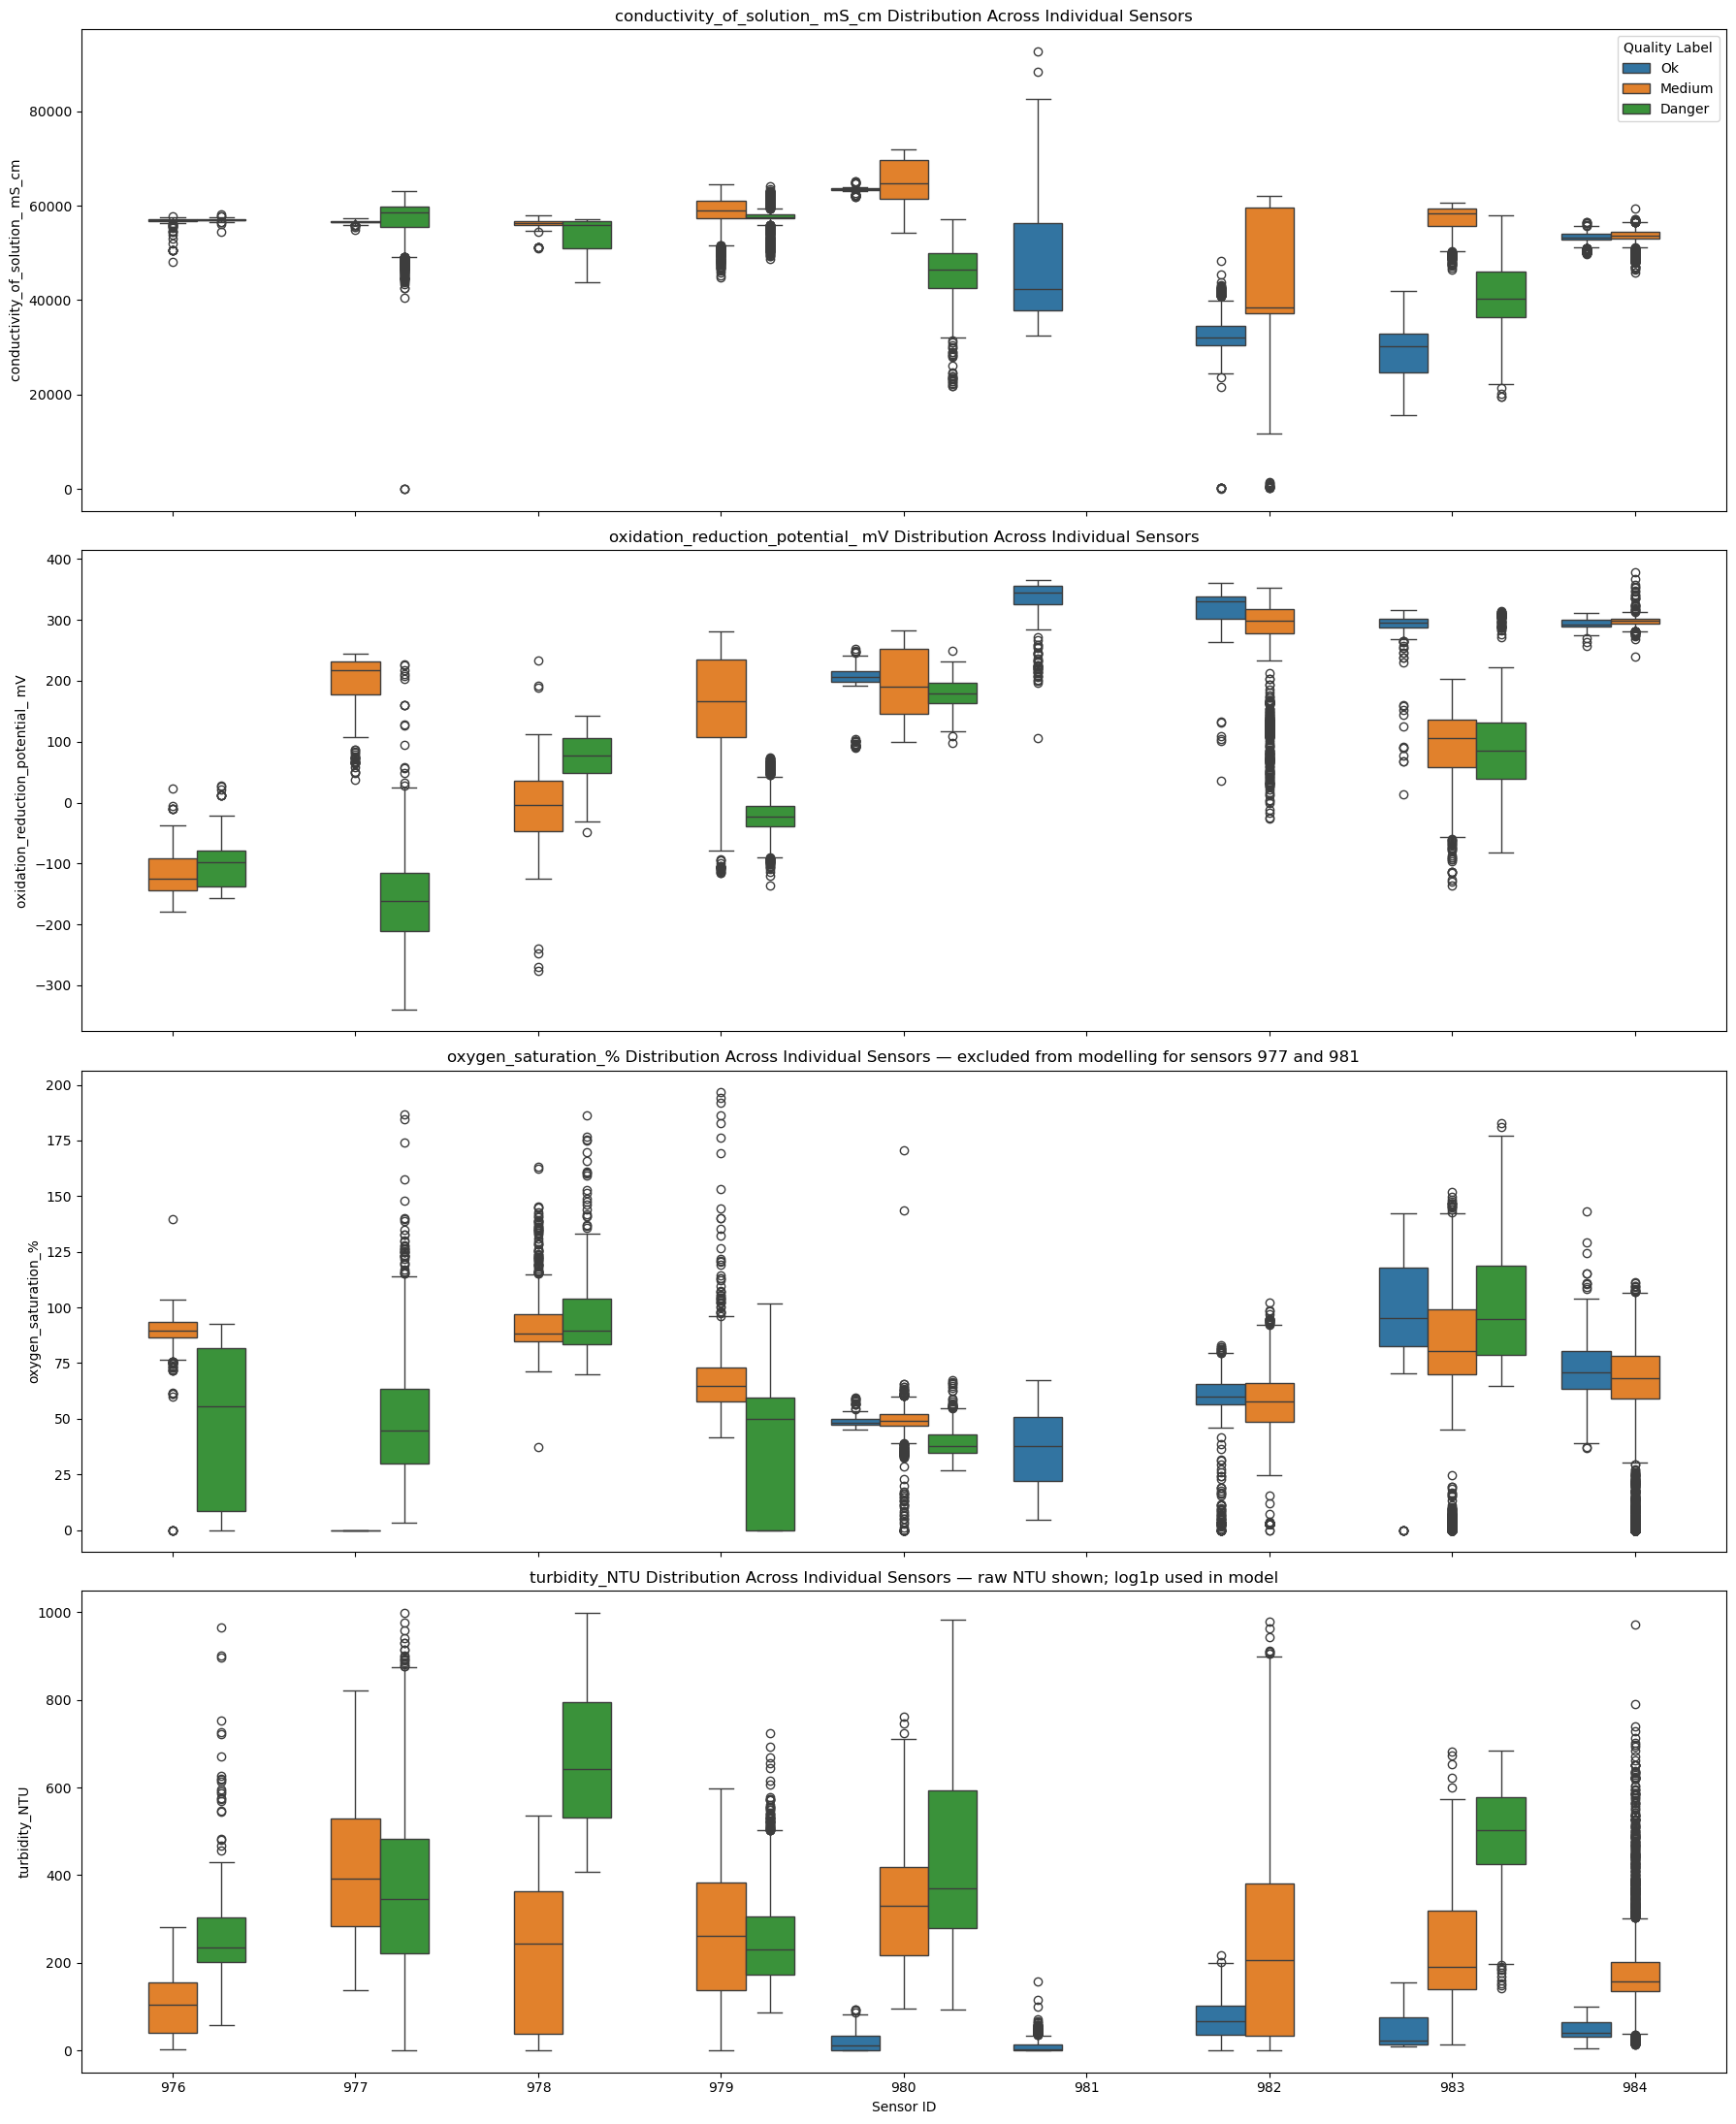

In [13]:
fig, axes = plt.subplots(
    nrows=len(all_features),
    ncols=1,
    figsize=(18, 22),
    sharex=True,
)

for position, (axis, feature) in enumerate(
    zip(axes, all_features)
):
    sns.boxplot(
        data=final_training_df,
        x=sensor_id_col,
        y=feature,
        hue="Water_Quality_Label",
        hue_order=label_order,
        ax=axis,
    )

    title = f"{feature} Distribution Across Individual Sensors"

    if feature == turbidity_col:
        title += " — raw NTU shown; log1p used in model"

    if feature == oxygen_col:
        title += " — excluded from modelling for sensors 977 and 981"

    axis.set_title(title)
    axis.set_ylabel(feature)

    if position < len(all_features) - 1:
        axis.set_xlabel("")

    if position == 0:
        axis.legend(
            title="Quality Label",
            loc="upper right",
        )
    elif axis.get_legend() is not None:
        axis.get_legend().remove()

axes[-1].set_xlabel("Sensor ID")

plt.tight_layout()
plt.show()


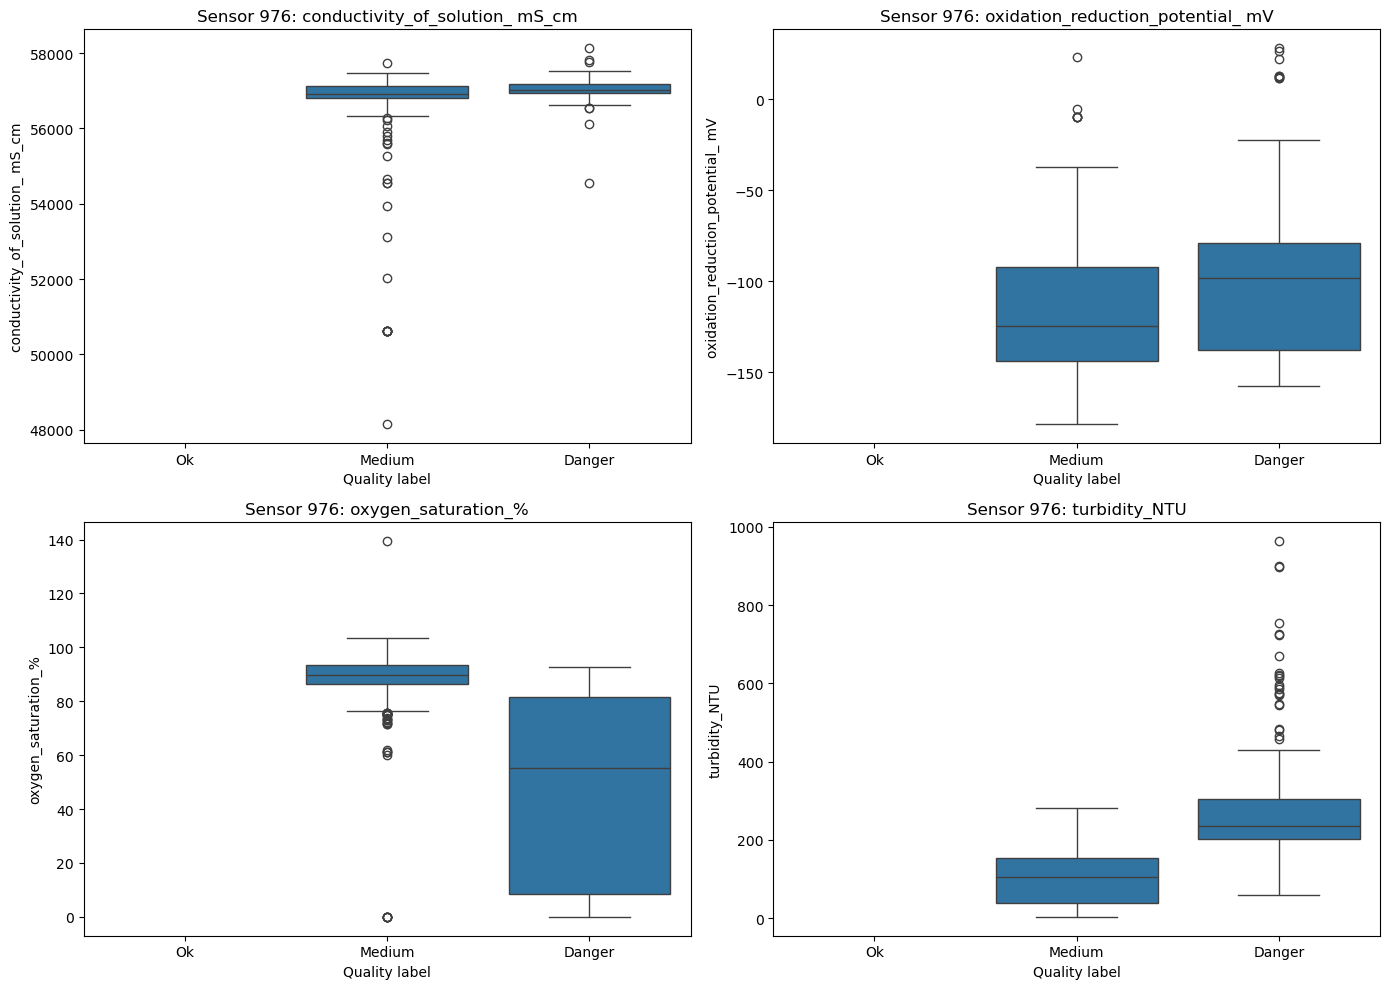

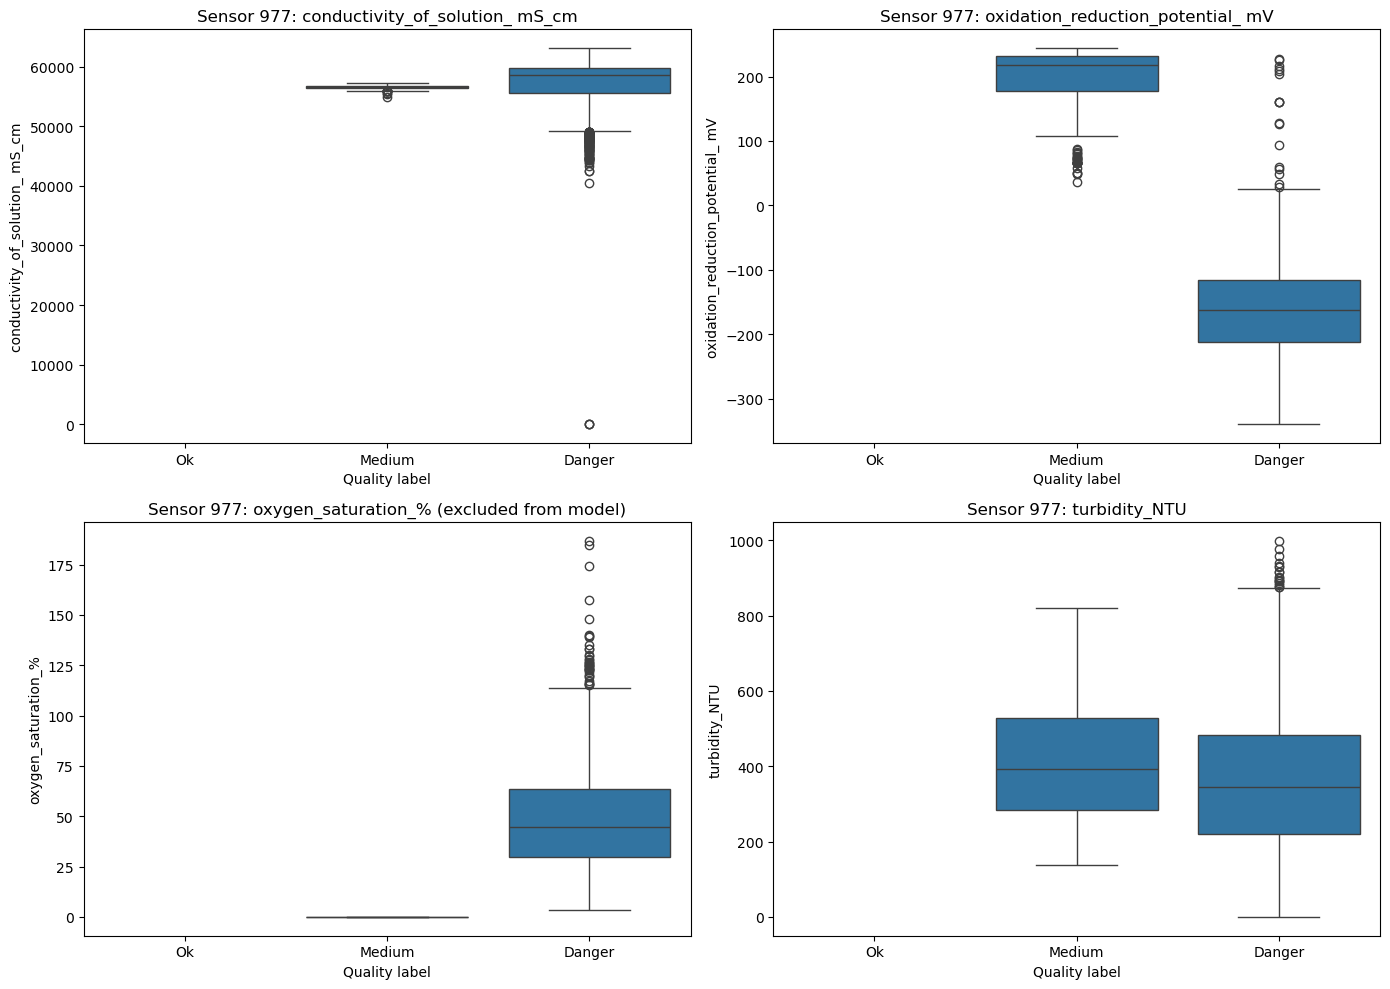

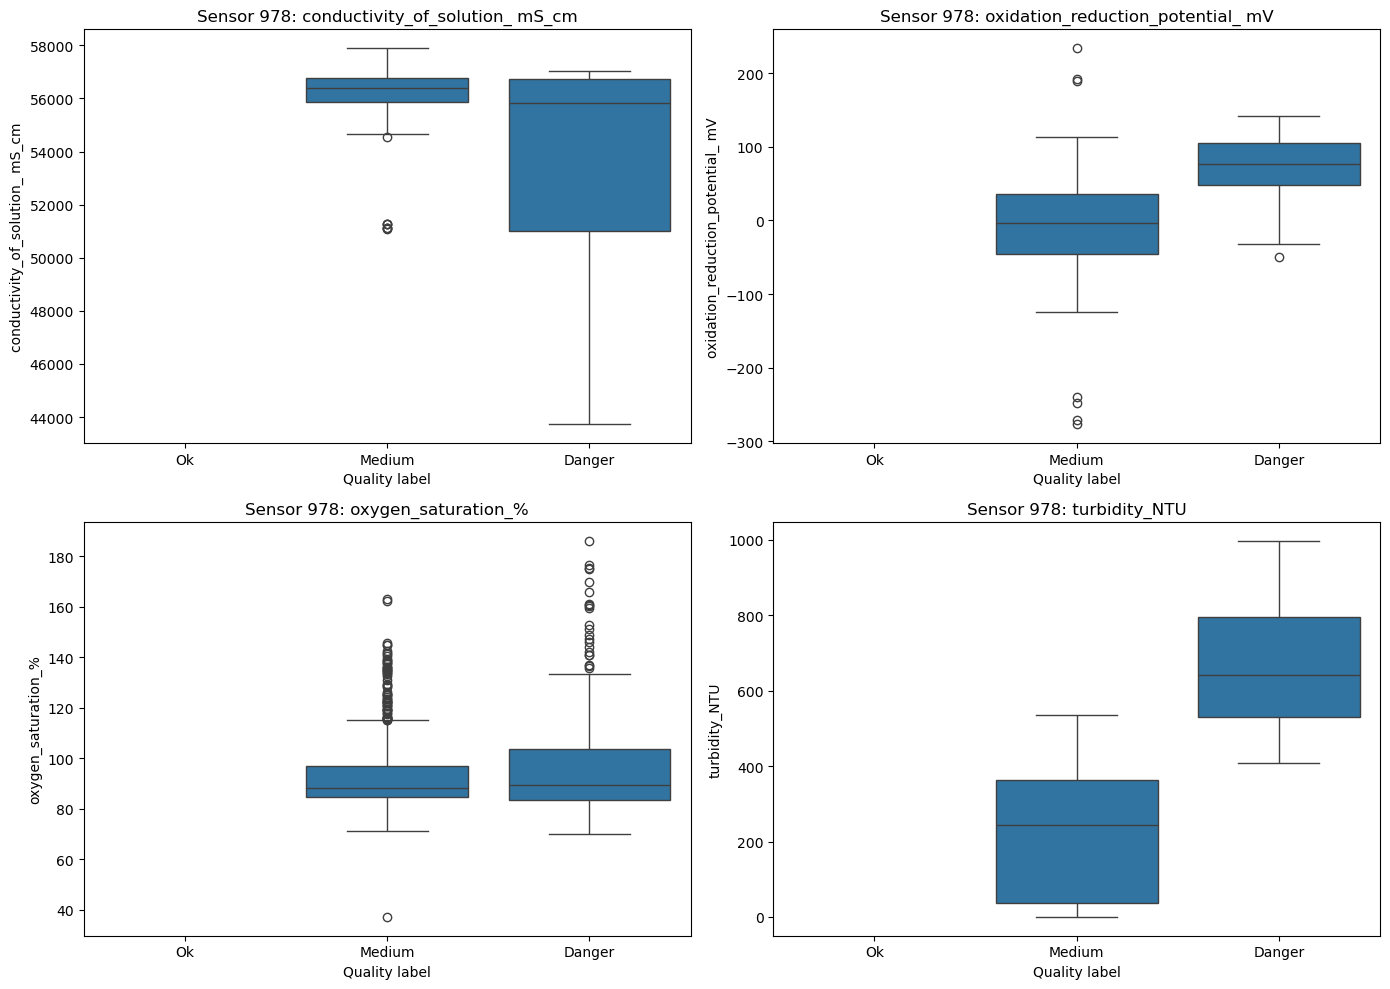

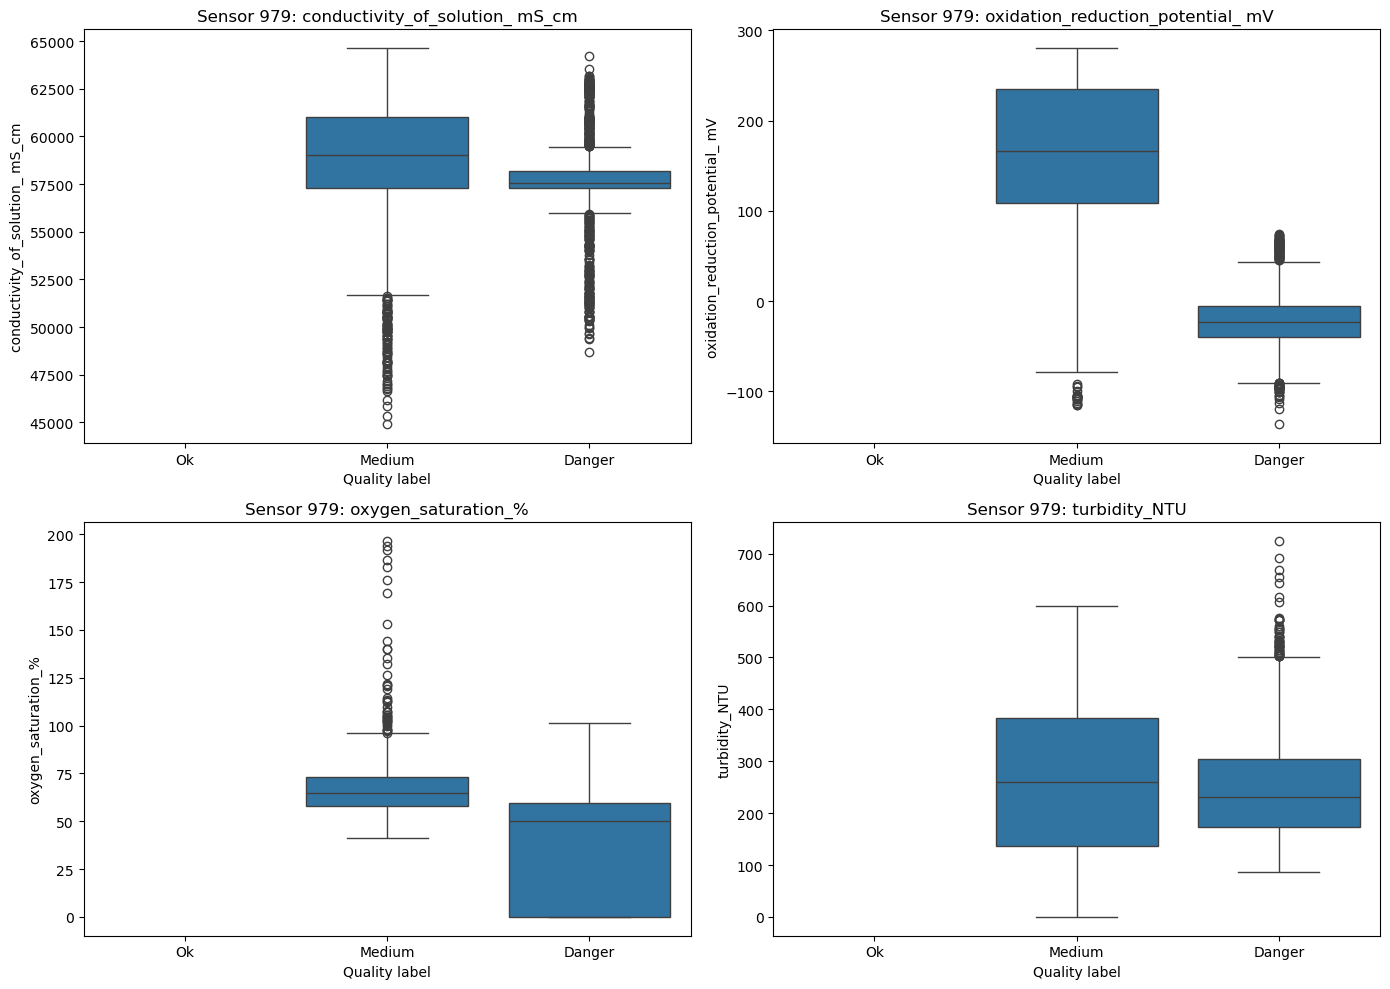

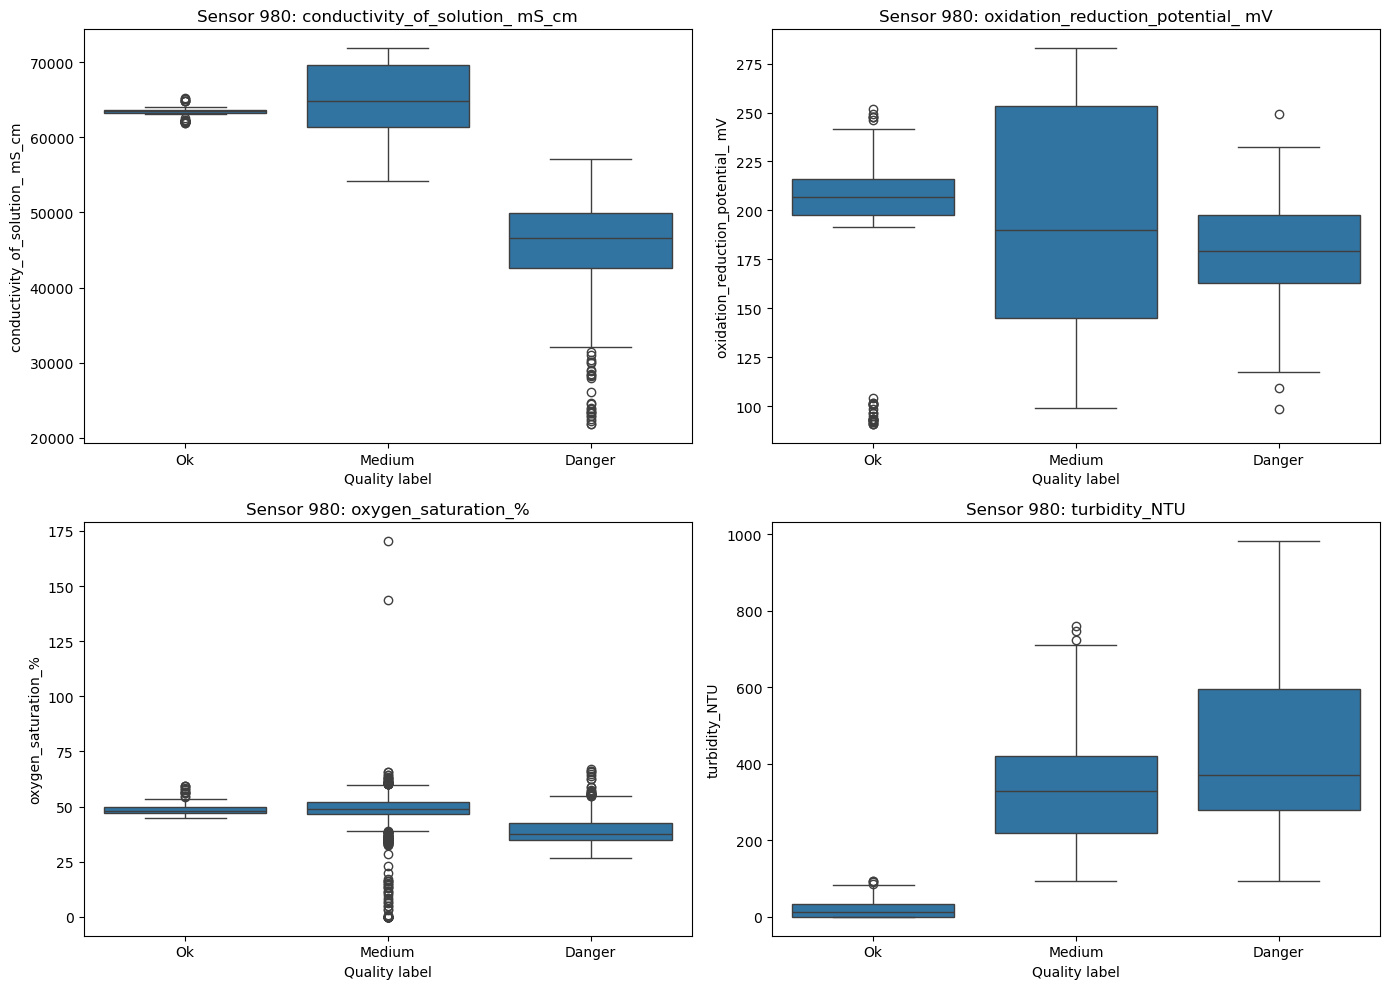

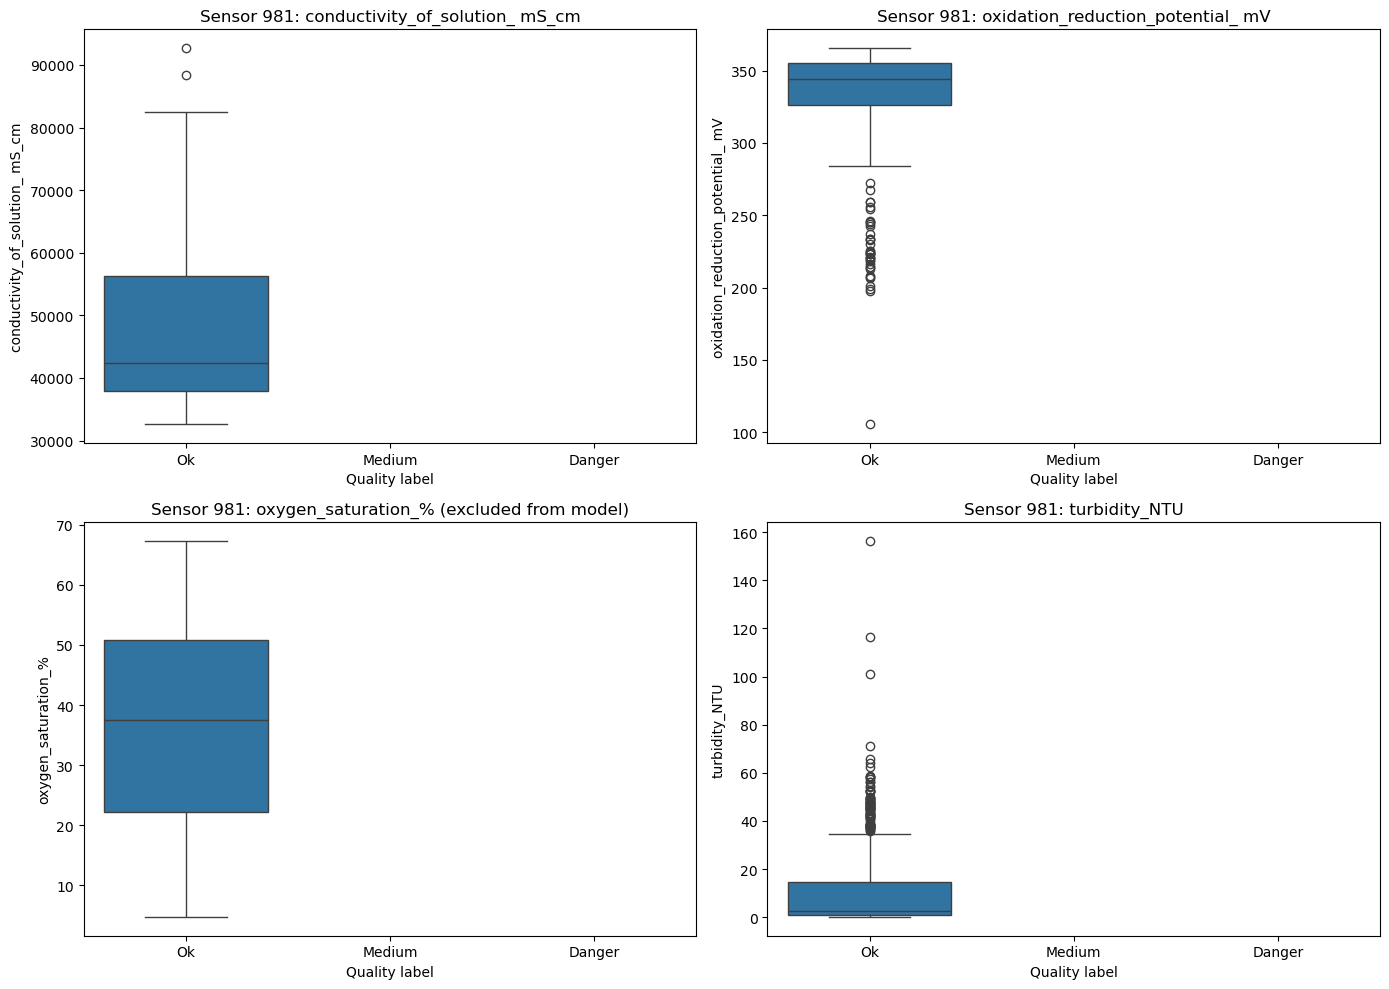

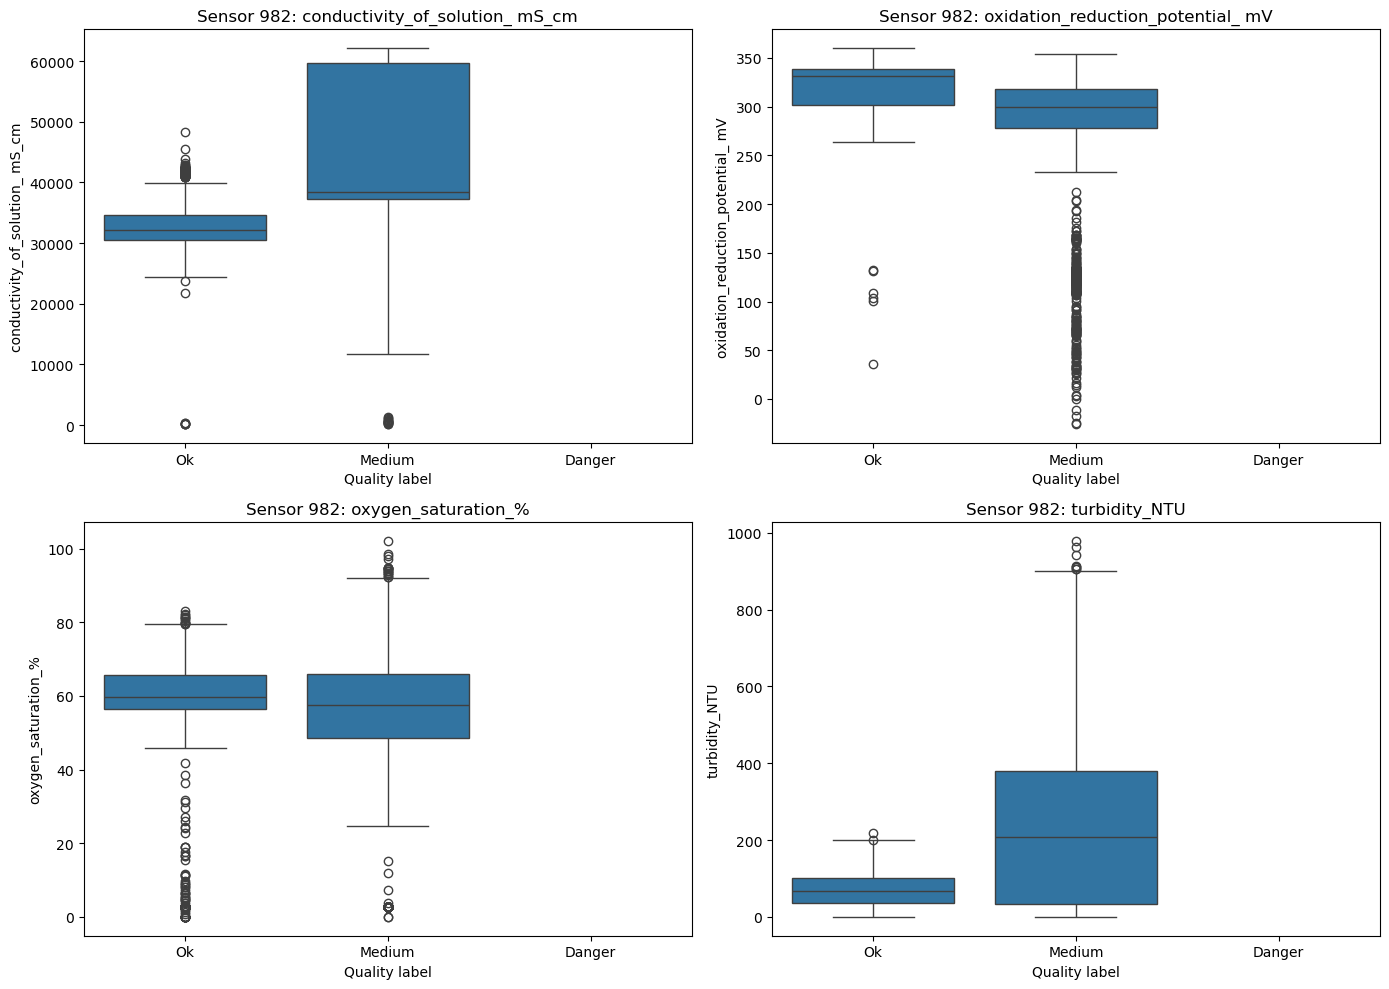

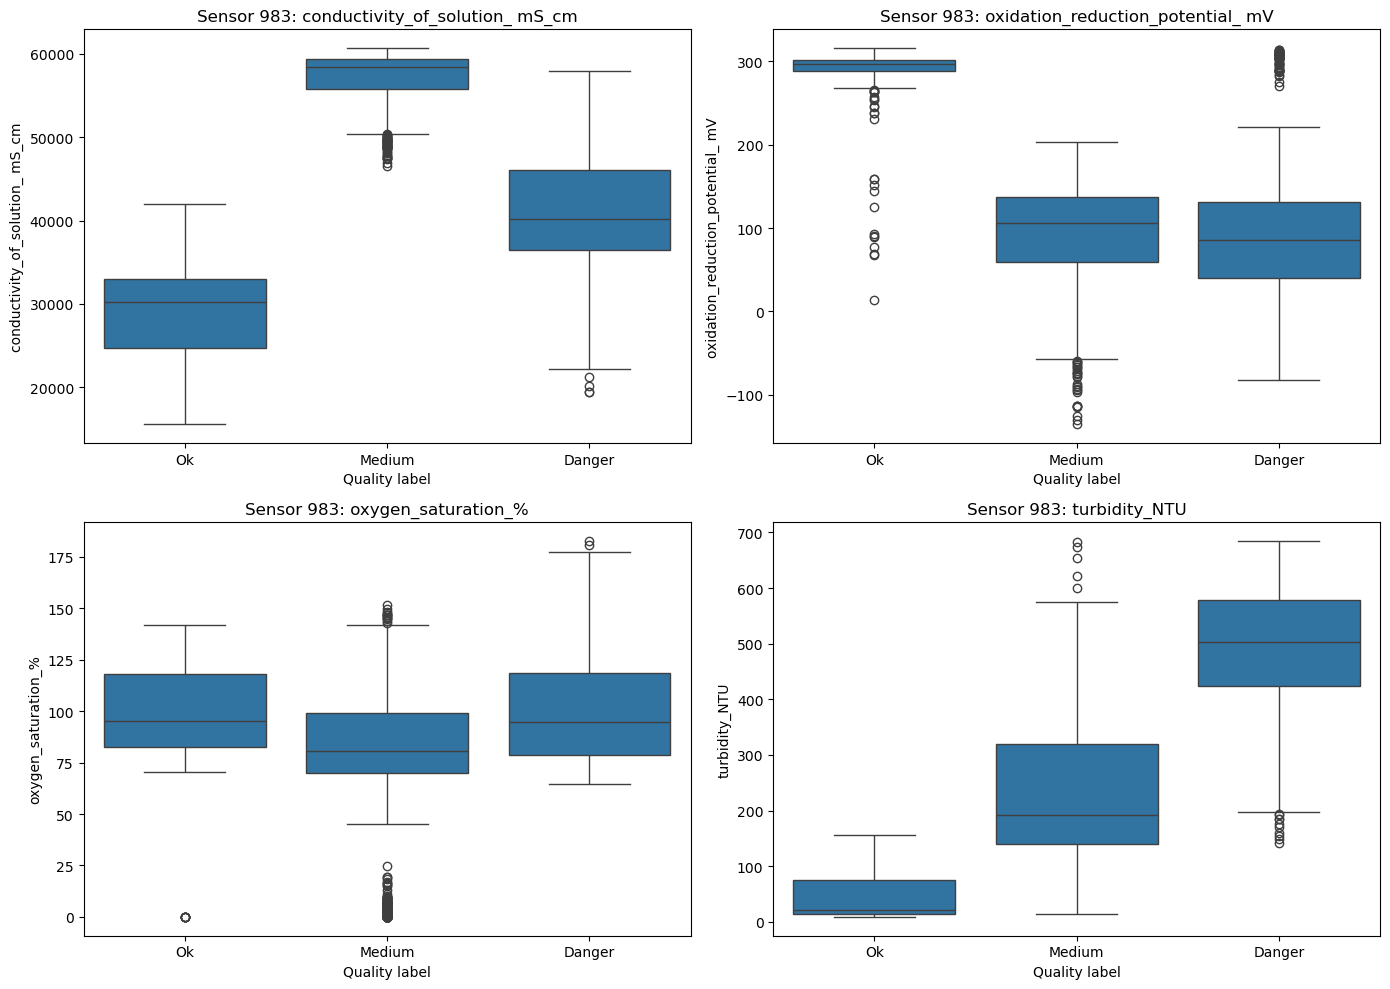

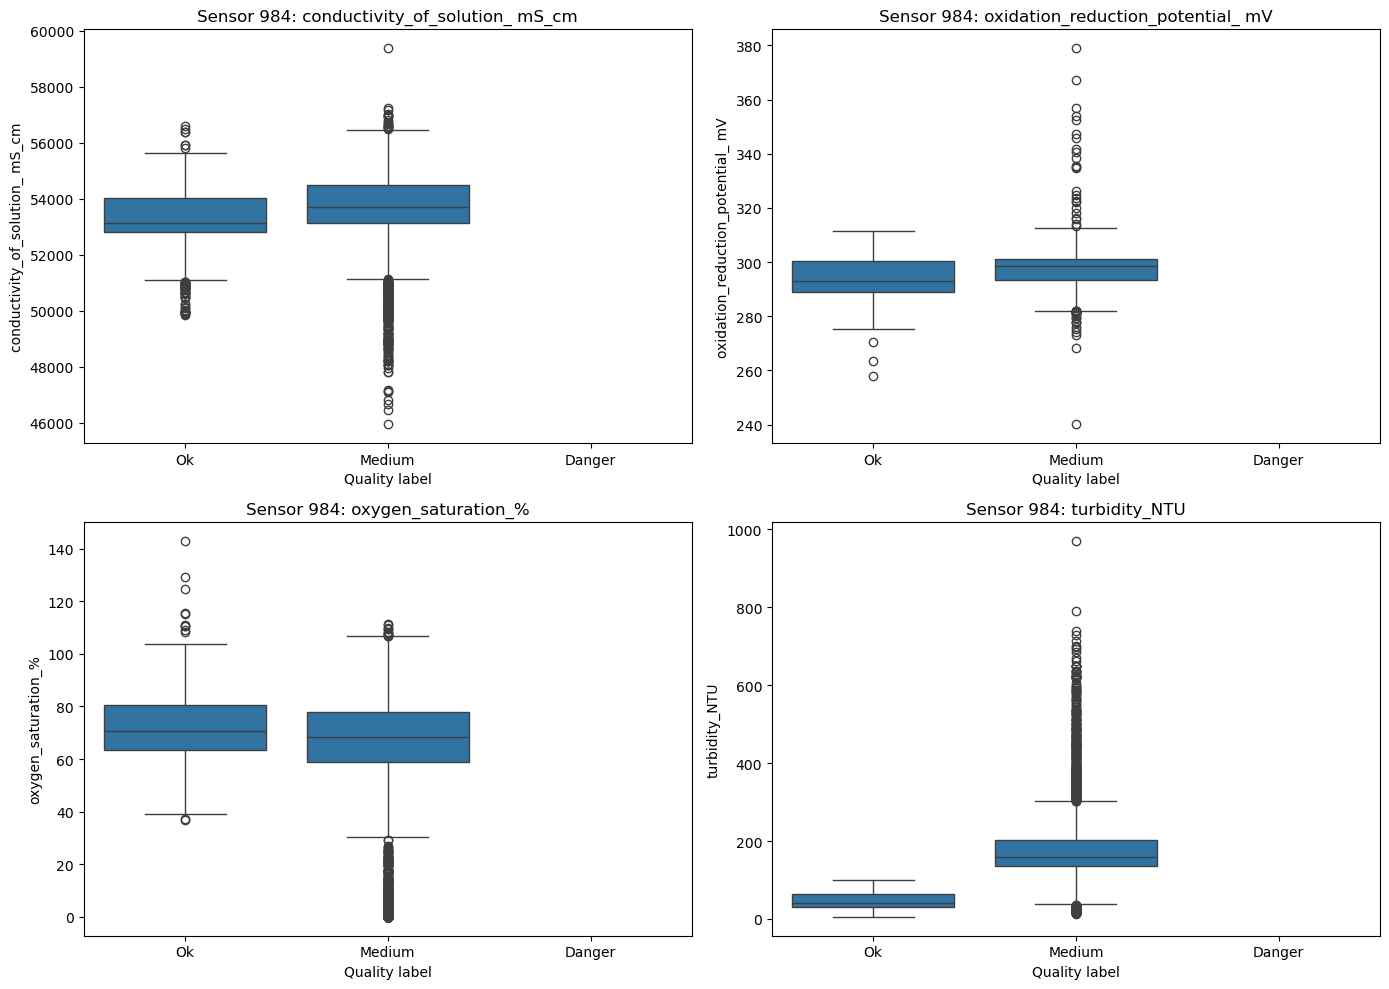

In [14]:
for sensor, sensor_data in final_training_df.groupby(
    sensor_id_col,
    sort=False,
):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10),
    )

    axes = axes.flatten()

    for axis, feature in zip(axes, all_features):
        sns.boxplot(
            data=sensor_data,
            x="Water_Quality_Label",
            y=feature,
            order=label_order,
            ax=axis,
        )

        title = f"Sensor {sensor}: {feature}"

        if (
            feature == oxygen_col
            and sensor in OXYGEN_EXCLUDED_SENSORS
        ):
            title += " (excluded from model)"

        axis.set_title(title)
        axis.set_xlabel("Quality label")

    plt.tight_layout()
    plt.show()


In [15]:
cluster_quality[
    [
        "sensor_id",
        "cluster",
        "cluster_quality_score",
        "Water_Quality_Label",
        "median_turbidity",
        "median_orp",
        "median_oxygen",
        "median_conductivity"
    ]
].sort_values("cluster_quality_score")

,sensor_id,cluster,cluster_quality_score,Water_Quality_Label,median_turbidity,median_orp,median_oxygen,median_conductivity
0,981,1,-0.823189,Ok,1.670,353.920,24.950,38404.530
1,981,2,-0.609651,Ok,2.005,325.775,59.825,61865.335
2,981,0,-0.557945,Ok,23.970,329.480,49.630,55841.990
3,983,2,-0.379195,Ok,21.510,296.210,95.240,30256.070
4,984,2,-0.364471,Ok,40.850,293.035,70.755,53142.385
5,980,2,-0.332766,Ok,12.250,206.650,48.210,63458.510
6,982,1,-0.304705,Ok,66.440,331.150,59.740,32133.370
7,978,1,-0.238132,Medium,21.910,-16.850,91.900,56699.090
8,984,0,-0.104617,Medium,189.210,297.400,71.430,53504.860
9,976,2,-0.039165,Medium,35.290,-140.750,93.340,56890.520


## 10. Contribution audit

The turbidity contribution is based on robust-scaled
`log1p(turbidity_NTU)`.

The oxygen contribution is zero for sensors 977 and 981.


In [16]:
cluster_contributions = clustered_df[
    [
        sensor_id_col,
        "cluster",
        "_row_id",
        "oxygen_used_in_model",
    ]
].copy()

cluster_contributions = cluster_contributions.set_index(
    "_row_id"
)

cluster_contributions[contribution_columns] = (
    label_scaled_df.loc[
        cluster_contributions.index,
        contribution_columns,
    ]
)

cluster_contributions = (
    cluster_contributions
    .groupby([sensor_id_col, "cluster"])
    .agg(
        **{
            column: (column, "median")
            for column in contribution_columns
        },
        oxygen_used_in_model=(
            "oxygen_used_in_model",
            "first",
        ),
    )
    .reset_index()
)

cluster_contributions = cluster_contributions.merge(
    cluster_quality[
        [
            sensor_id_col,
            "cluster",
            "cluster_quality_score",
            "Water_Quality_Label",
            "model_features",
        ]
    ],
    on=[sensor_id_col, "cluster"],
    how="left",
)

display(
    cluster_contributions.sort_values(
        [sensor_id_col, "cluster_quality_score"]
    )
)


,sensor_id,cluster,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,cluster_quality_score,Water_Quality_Label,model_features
2,976,2,-1.957761,2.060681,-0.680944,0.327878,True,-0.039165,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
0,976,0,-0.371665,1.895624,-0.545554,0.719585,True,0.320349,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
1,976,1,0.269612,1.775909,0.236661,0.432634,True,0.547025,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
4,977,1,1.007450,-0.349389,0.000000,0.416507,False,0.246924,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
3,977,0,-0.066682,2.251707,0.000000,0.416167,False,0.534134,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
5,977,2,1.195860,2.173770,0.000000,0.757528,False,0.883851,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
7,978,1,-2.321694,1.227152,-0.646098,0.519770,True,-0.238132,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
8,978,2,0.805722,1.115981,-0.524138,0.441577,True,0.292091,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
6,978,0,1.740548,0.597531,-0.586812,0.631229,True,0.429275,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
11,979,2,-2.124048,0.671196,-0.015971,0.244785,True,0.061193,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."


## 11. Optional inspection helper


SENSOR 977
Observations: 1848
Silhouette score: 0.4350

Label distribution:


,observations,percentage
Water_Quality_Label,,
Medium,400,21.645
Danger,1448,78.355



Cluster summary:


,cluster,Water_Quality_Label,observations,cluster_quality_score,conductivity_of_solution_ mS_cm_mean,conductivity_of_solution_ mS_cm_median,oxidation_reduction_potential_ mV_mean,oxidation_reduction_potential_ mV_median,oxygen_saturation_%_mean,oxygen_saturation_%_median,turbidity_NTU_mean,turbidity_NTU_median
1,1,Medium,400,0.247,56597.071,56617.220,199.418,217.495,0.000,0.00,406.078,392.980
0,0,Danger,544,0.534,57902.124,58717.845,-169.538,-169.145,39.863,32.43,179.673,184.965
2,2,Danger,904,0.884,56520.616,58526.070,-162.712,-157.560,55.816,55.27,486.785,446.300



Statistics by quality label:


conductivity_of_solution_ mS_cm                        \
                                              count       mean     median   
Water_Quality_Label                                                         
Medium                                          400  56597.071  56617.220   
Danger                                         1448  57039.635  58628.765   

                                                   \
                          std       min       max   
Water_Quality_Label                                 
Medium                301.502  54884.96  57276.01   
Danger               4839.836      0.00  63089.16   

                    oxidation_reduction_potential_ mV                    \
                                                count     mean   median   
Water_Quality_Label                                                       
Medium                                            400  199.418  217.495   
Danger                                           1448 -165.277 -161.655   

                             ... oxygen_saturation_%                       \
                        std  ...              median     std   min    max   
Water_Quality_Label          ...                                            
Medium               45.185  ...                0.00   0.000  0.00    0.0   
Danger               76.696  ...               44.72  23.936  3.36  186.9   

                    turbidity_NTU                                            
                            count     mean  median      std     min     max  
Water_Quality_Label                                                          
Medium                        400  406.078  392.98  155.682  138.72  821.32  
Danger                       1448  371.406  344.71  200.268    0.10  999.03  

[2 rows x 24 columns]


Cluster score contributions:


,sensor_id,cluster,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,cluster_quality_score,Water_Quality_Label,model_features
4,977,1,1.007,-0.349,0.0,0.417,False,0.247,Medium,"conductivity_of_solution_ mS_cm, oxidation_red..."
3,977,0,-0.067,2.252,0.0,0.416,False,0.534,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."
5,977,2,1.196,2.174,0.0,0.758,False,0.884,Danger,"conductivity_of_solution_ mS_cm, oxidation_red..."


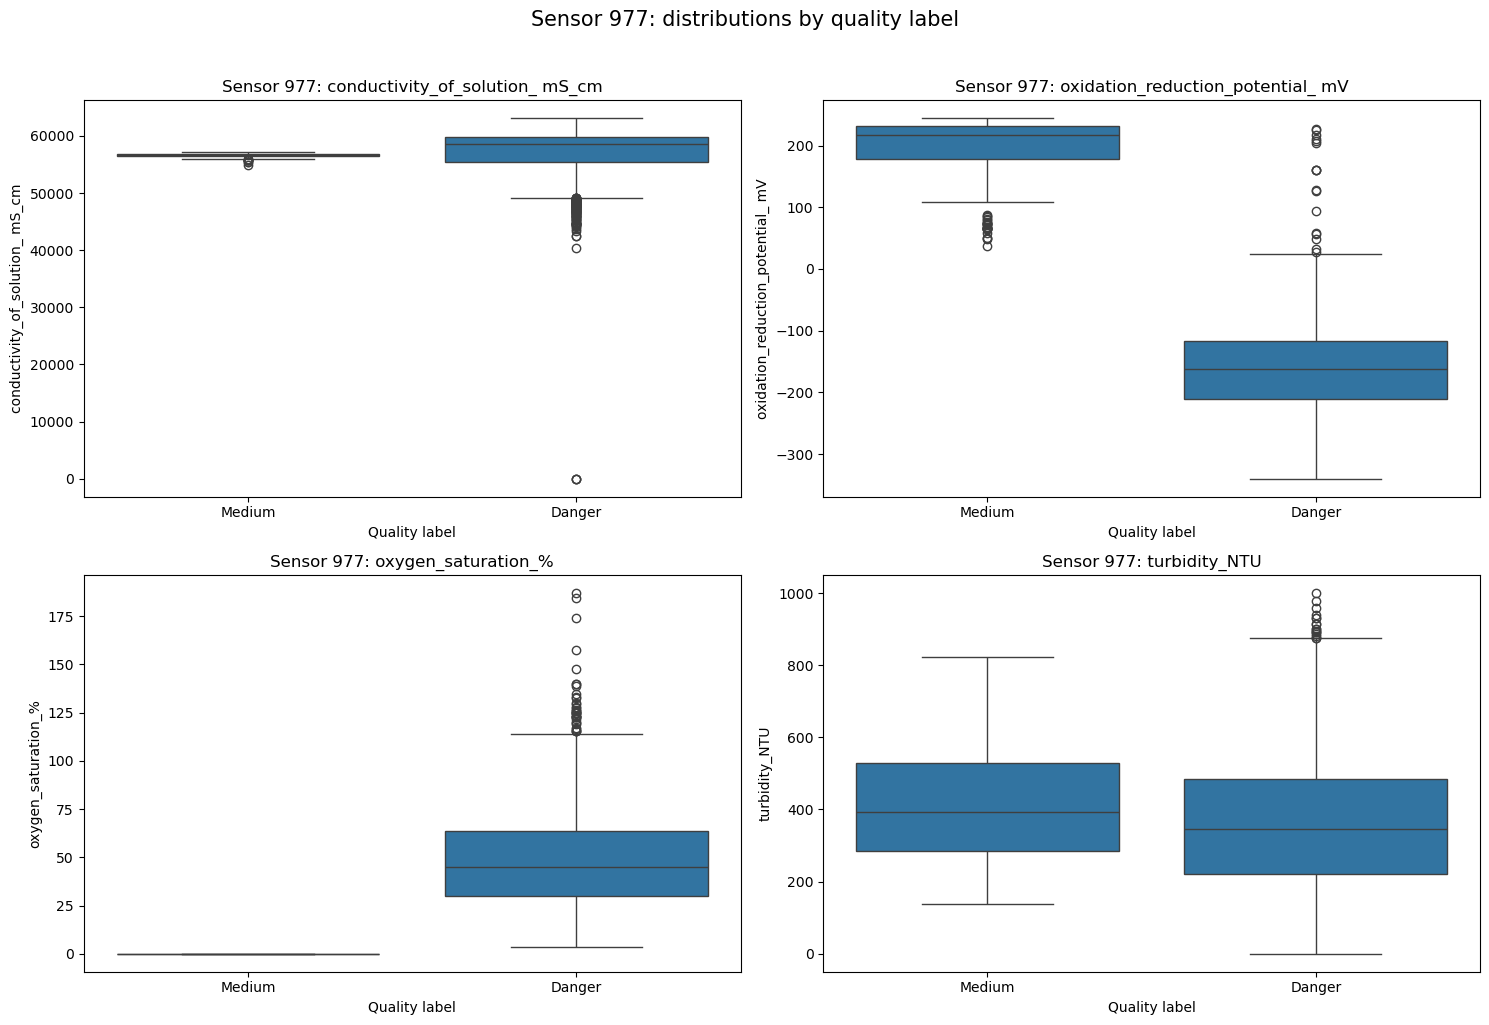

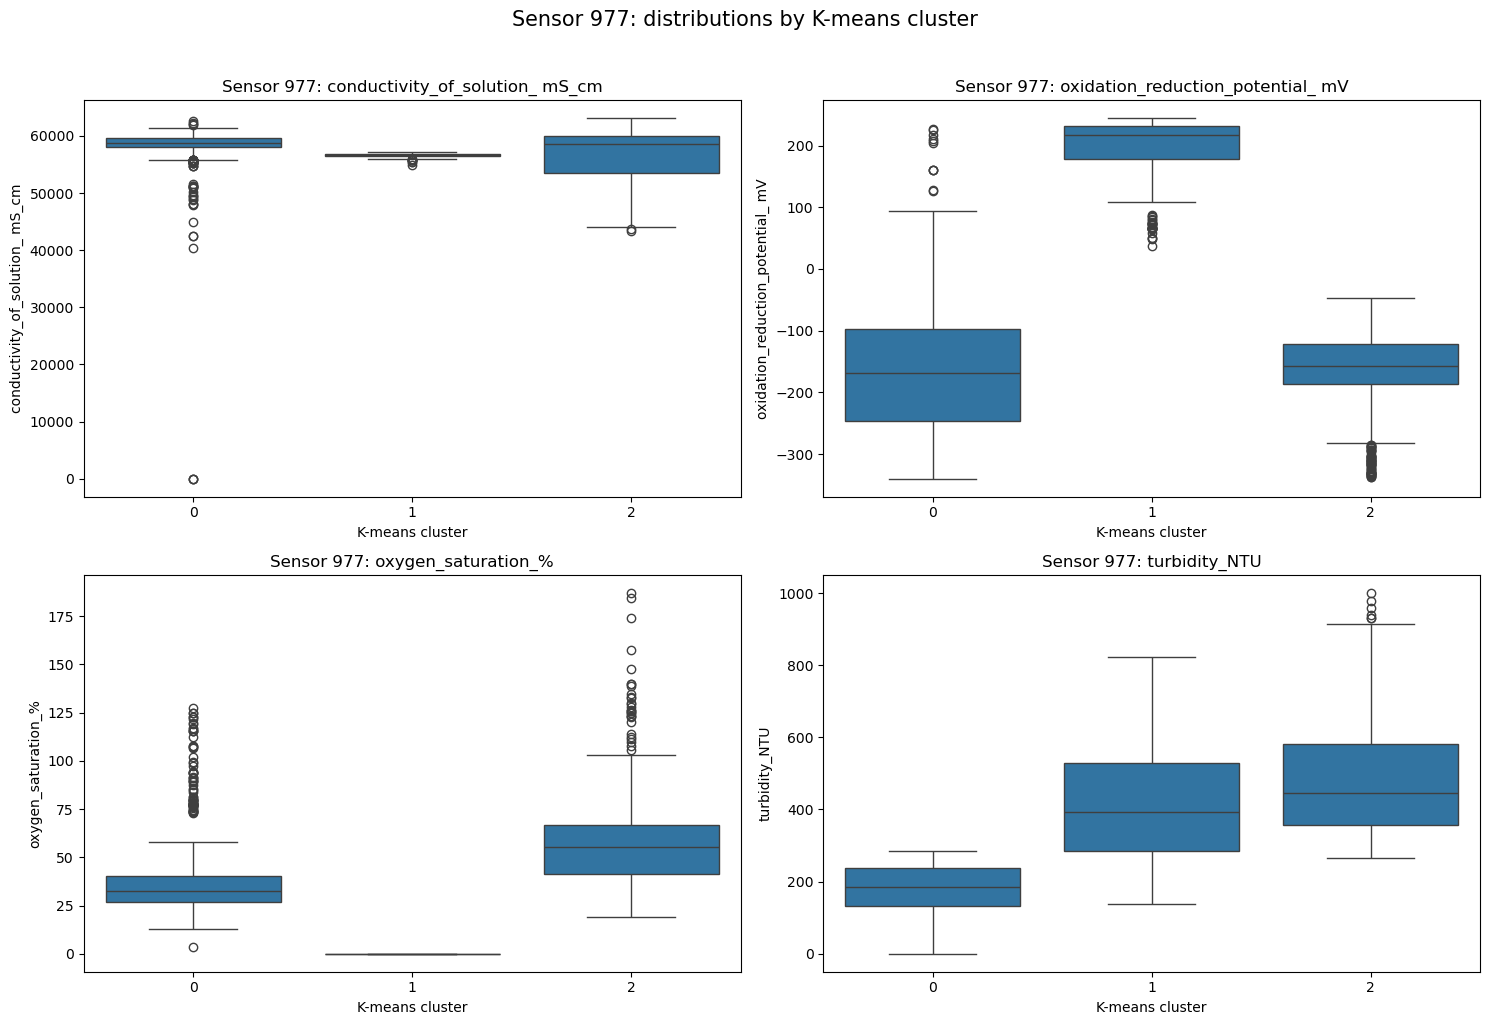

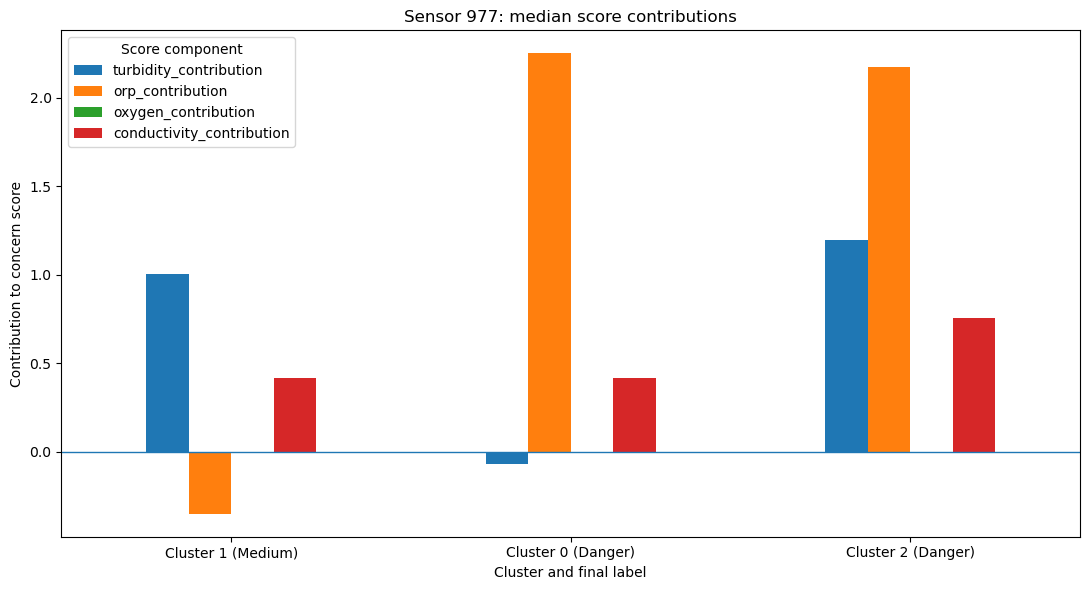

In [17]:
SENSOR_TO_INSPECT = 977

if inspect_sensors is not None:
    inspection = inspect_sensors(
        SENSOR_TO_INSPECT,
        final_training_df,
        cluster_contributions=cluster_contributions,
        silhouette_df=silhouette_df,
    )
else:
    print(
        "inspect_sensors was not loaded. "
        "The clustering results above are still available."
    )


## 12. Optional dashboard-ready latest statuses

The dashboard still returns the original turbidity value in NTU.

For sensors 977 and 981, the returned status uses conductivity, ORP, and
log-transformed turbidity only. The raw oxygen value may still be displayed,
but the output explicitly notes that oxygen was excluded.


In [18]:
if build_latest_sensor_statuses is not None:
    latest_sensor_statuses = build_latest_sensor_statuses(
        final_training_df,
        cluster_contributions,
        timestamp_col=timestamp_col,
    )

    latest_sensor_statuses["oxygen_used_in_model"] = (
        ~latest_sensor_statuses[sensor_id_col].isin(
            OXYGEN_EXCLUDED_SENSORS
        )
    )

    latest_sensor_statuses["model_note"] = np.where(
        latest_sensor_statuses["oxygen_used_in_model"],
        "Conductivity, ORP, oxygen and log-transformed turbidity used",
        (
            "Oxygen excluded due to suspected sensor drift; "
            "status uses conductivity, ORP and log-transformed turbidity"
        ),
    )

    display(latest_sensor_statuses)
else:
    latest_sensor_statuses = None
    print(
        "build_latest_sensor_statuses was not loaded. "
        "Skip the remaining website-output cells."
    )


,sensor_id,date_insert,Water_Quality_Label,status_rank,cluster,cluster_quality_score,main_driver,explanation,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,oxygen_saturation_%,turbidity_NTU,turbidity_contribution,orp_contribution,oxygen_contribution,conductivity_contribution,oxygen_used_in_model,model_note
0,976,2025-11-05 09:00:00,Danger,2,1,0.547025,ORP,High concern is mainly associated with low ORP.,58135.10,28.13,0.00,901.18,0.269612,1.775909,0.236661,0.432634,True,"Conductivity, ORP, oxygen and log-transformed ..."
1,977,2026-01-24 15:00:00,Danger,2,0,0.534134,ORP,High concern is mainly associated with low ORP.,0.36,-55.21,NaN,0.86,-0.066682,2.251707,0.000000,0.416167,False,Oxygen excluded due to suspected sensor drift;...
2,978,2025-12-25 03:00:00,Medium,1,2,0.292091,ORP,Moderate concern is mainly associated with low...,55823.70,9.61,37.11,435.74,0.805722,1.115981,-0.524138,0.441577,True,"Conductivity, ORP, oxygen and log-transformed ..."
3,979,2026-04-11 09:00:00,Danger,2,1,0.460858,ORP,High concern is mainly associated with low ORP.,64206.19,-39.64,0.77,577.06,0.241442,1.271284,0.367090,0.234512,True,"Conductivity, ORP, oxygen and log-transformed ..."
4,980,2025-12-12 17:00:00,Medium,1,0,0.286202,Turbidity,Moderate concern is mainly associated with ele...,66961.40,207.18,0.00,297.02,0.752746,-0.163477,0.395402,0.629841,True,"Conductivity, ORP, oxygen and log-transformed ..."
5,981,2025-09-18 19:00:00,Ok,0,1,-0.823189,Turbidity,"Overall concern is low, mainly because of low ...",43035.56,318.87,4.74,6.35,-3.105877,-1.267180,0.000000,0.218905,False,Oxygen excluded due to suspected sensor drift;...
6,982,2026-01-26 02:00:00,Medium,1,2,0.009979,Conductivity,Moderate concern is mainly associated with con...,61393.21,150.61,2.79,55.81,-2.271148,-0.756904,0.282880,3.287343,True,"Conductivity, ORP, oxygen and log-transformed ..."
7,983,2026-04-16 06:00:00,Medium,1,1,0.076705,ORP,Moderate concern is mainly associated with low...,57002.71,67.51,0.00,31.55,-0.018297,0.398298,-0.368421,0.190664,True,"Conductivity, ORP, oxygen and log-transformed ..."
8,984,2026-01-08 11:00:00,Medium,1,1,0.005821,Oxygen saturation,Moderate concern is mainly associated with low...,56056.12,301.04,1.71,138.56,-1.773033,-0.902351,1.513854,1.241963,True,"Conductivity, ORP, oxygen and log-transformed ..."


In [19]:
if latest_sensor_statuses is not None:
    website_cards = latest_sensor_statuses[
        [
            sensor_id_col,
            timestamp_col,
            "Water_Quality_Label",
            "main_driver",
            "explanation",
            "cluster_quality_score",
            "oxygen_used_in_model",
            "model_note",
            turbidity_col,
            orp_col,
            oxygen_col,
            conductivity_col,
        ]
    ]

    display(website_cards)


,sensor_id,date_insert,Water_Quality_Label,main_driver,explanation,cluster_quality_score,oxygen_used_in_model,model_note,turbidity_NTU,oxidation_reduction_potential_ mV,oxygen_saturation_%,conductivity_of_solution_ mS_cm
0,976,2025-11-05 09:00:00,Danger,ORP,High concern is mainly associated with low ORP.,0.547025,True,"Conductivity, ORP, oxygen and log-transformed ...",901.18,28.13,0.00,58135.10
1,977,2026-01-24 15:00:00,Danger,ORP,High concern is mainly associated with low ORP.,0.534134,False,Oxygen excluded due to suspected sensor drift;...,0.86,-55.21,NaN,0.36
2,978,2025-12-25 03:00:00,Medium,ORP,Moderate concern is mainly associated with low...,0.292091,True,"Conductivity, ORP, oxygen and log-transformed ...",435.74,9.61,37.11,55823.70
3,979,2026-04-11 09:00:00,Danger,ORP,High concern is mainly associated with low ORP.,0.460858,True,"Conductivity, ORP, oxygen and log-transformed ...",577.06,-39.64,0.77,64206.19
4,980,2025-12-12 17:00:00,Medium,Turbidity,Moderate concern is mainly associated with ele...,0.286202,True,"Conductivity, ORP, oxygen and log-transformed ...",297.02,207.18,0.00,66961.40
5,981,2025-09-18 19:00:00,Ok,Turbidity,"Overall concern is low, mainly because of low ...",-0.823189,False,Oxygen excluded due to suspected sensor drift;...,6.35,318.87,4.74,43035.56
6,982,2026-01-26 02:00:00,Medium,Conductivity,Moderate concern is mainly associated with con...,0.009979,True,"Conductivity, ORP, oxygen and log-transformed ...",55.81,150.61,2.79,61393.21
7,983,2026-04-16 06:00:00,Medium,ORP,Moderate concern is mainly associated with low...,0.076705,True,"Conductivity, ORP, oxygen and log-transformed ...",31.55,67.51,0.00,57002.71
8,984,2026-01-08 11:00:00,Medium,Oxygen saturation,Moderate concern is mainly associated with low...,0.005821,True,"Conductivity, ORP, oxygen and log-transformed ...",138.56,301.04,1.71,56056.12


In [20]:
if latest_sensor_statuses is not None:
    website_records = (
        website_cards
        .replace({np.nan: None})
        .to_dict(orient="records")
    )

    website_records


In [21]:
OUTPUT_PATH = r"C:\Users\User\Desktop\water\data\labeled_water_stats_log_turbidity.csv"

final_training_df.to_csv(
    OUTPUT_PATH,
    index=False,
)

print(f"Saved: {OUTPUT_PATH}")


Saved: C:\Users\User\Desktop\water\data\labeled_water_stats_log_turbidity.csv


In [23]:
DEPLOYMENT_MODEL_PATH = "water_quality_frozen_clusters.pkl"

deployment_bundle = {
    # Frozen preprocessing
    "feature_scalers": feature_scalers,
    "sensor_feature_sets": sensor_feature_sets,
    "clustering_weights": clustering_weights,

    # Frozen KMeans models / centroids
    "sensor_kmeans_models": sensor_kmeans_models,

    # Frozen cluster -> label relationship
    "cluster_labels": cluster_quality[
        [
            sensor_id_col,
            "cluster",
            "cluster_quality_score",
            "Water_Quality_Label",
        ]
    ].copy(),

    # Keep the contribution information used for explanations
    "cluster_contributions": cluster_contributions.copy(),

    # Current modelling configuration
    "oxygen_excluded_sensors": OXYGEN_EXCLUDED_SENSORS,
    "turbidity_transform": {
        "type": "log1p_divide",
        "divisor": 30.0,
    },

    # Saved for documentation/reproducibility.
    # These should NOT be recalculated from deployment data.
    "ok_cutoff": float(ok_cutoff),
    "danger_cutoff": float(danger_cutoff),

    "n_clusters": N_CLUSTERS,
}

joblib.dump(
    deployment_bundle,
    DEPLOYMENT_MODEL_PATH,
)

print(
    f"Frozen deployment model saved to: "
    f"{DEPLOYMENT_MODEL_PATH}"
)

Frozen deployment model saved to: water_quality_frozen_clusters.pkl


In [6]:
temp = df['sensor_id'].unique().tolist()

In [12]:
temp

[976, 977, 978, 979, 980, 981, 982, 983, 984]

In [17]:
for i in temp:
    print(i)
    print(df[df['sensor_id'] == i]['oxygen_saturation_%'].tail())

976
1252    0.0
1253    0.0
1254    0.0
1255    0.0
1256    0.0
Name: oxygen_saturation_%, dtype: float64
977
3100   NaN
3101   NaN
3102   NaN
3103   NaN
3104   NaN
Name: oxygen_saturation_%, dtype: float64
978
4684    85.90
4685    84.58
4686    84.02
4687    83.27
4688    37.11
Name: oxygen_saturation_%, dtype: float64
979
8125    19.40
8126    11.98
8127    24.32
8128    11.75
8129     0.77
Name: oxygen_saturation_%, dtype: float64
980
10333     0.00
10334     0.00
10335     0.00
10336    20.01
10337     0.00
Name: oxygen_saturation_%, dtype: float64
981
11319    10.93
11320    10.61
11321    11.35
11322    11.20
11323     4.74
Name: oxygen_saturation_%, dtype: float64
982
14445    2.79
14446    2.79
14447    2.79
14448    2.79
14449    2.79
Name: oxygen_saturation_%, dtype: float64
983
16968    0.0
16969    0.0
16970    0.0
16971    0.0
16972    0.0
Name: oxygen_saturation_%, dtype: float64
984
19852     3.13
19853     1.25
19854    30.35
19855     9.08
19856     1.71
Name: oxygen_

In [27]:
df.columns

Index(['date_insert', 'sensor_id', 'id', 'year', 'month', 'day', 'hour', 'lat',
       'lng', 'wtempV_°C', 'conductivity_of_solution_ mS_cm',
       'oxidation_reduction_potential_ mV', 'total_suspended_solids_mg_L',
       'turbidity_NTU', 'dissolved_oxygen_concentration _ppm',
       'dissolved_oxygen_concentration_mg_L', 'oxygen_saturation_%',
       'salinity_ppt', 'dissolved_solids _ppm', 'location', '_source_row_id',
       '_row_id', 'wtempV_°C__sentinel_invalid',
       'conductivity_of_solution_ mS_cm__sentinel_invalid',
       'oxidation_reduction_potential_ mV__sentinel_invalid',
       'oxygen_saturation_%__sentinel_invalid',
       'turbidity_NTU__sentinel_invalid', 'wtempV_°C__hard_limit_invalid',
       'conductivity_of_solution_ mS_cm__hard_limit_invalid',
       'oxidation_reduction_potential_ mV__hard_limit_invalid',
       'oxygen_saturation_%__hard_limit_invalid',
       'turbidity_NTU__hard_limit_invalid', 'oxygen_saturation_original',
       'oxygen_below_1_flag',

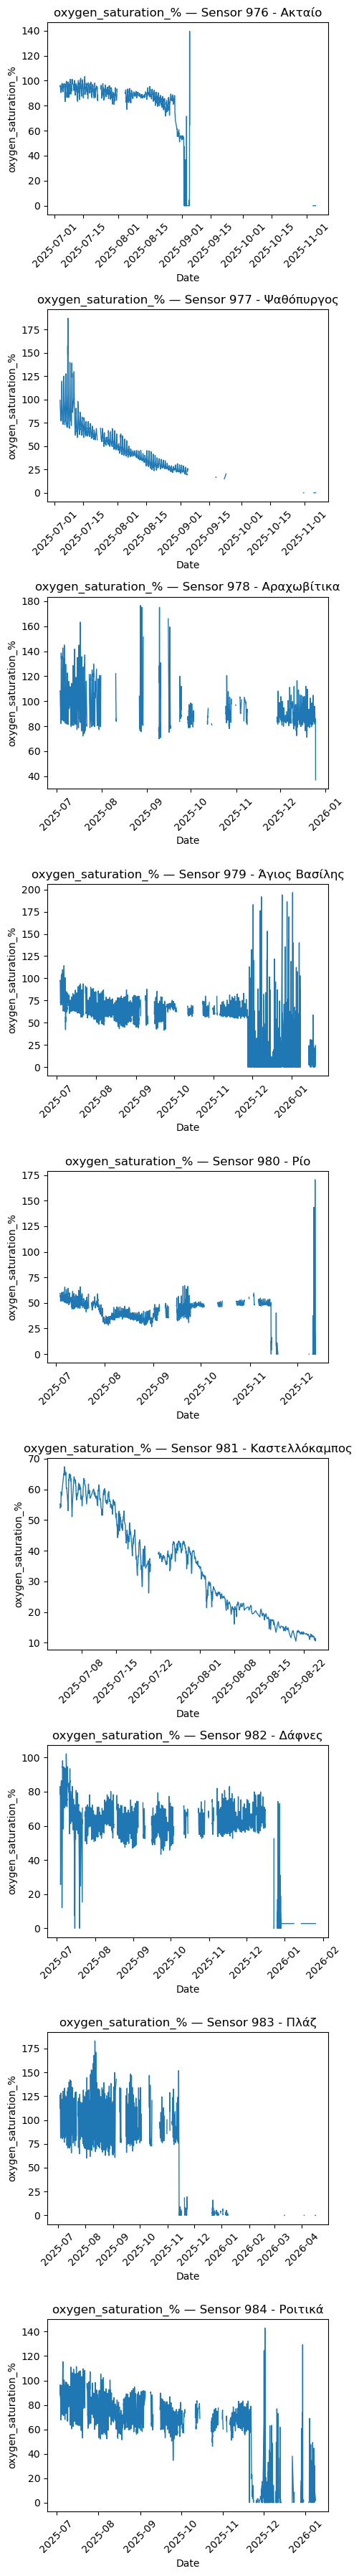

In [7]:
plot_sensors(temp,['oxygen_saturation_%'],df)